# Wavelet Explanation Pipeline — Self-Contained Notebook

This notebook distills the entire `wavelet_explanation/` training pipeline into a single, step-by-step notebook. It trains a U-Net to produce sparse binary masks in the Haar wavelet domain that explain a frozen classifier's decisions.

**Pipeline:**
1. Load a YAML config (same configs used by `train.py`)
2. Build the Haar DWT, U-Net mask generator, and frozen classifier
3. Train the U-Net with the full loss suite (L_act, L_CE, L_KL, L_rob, L_area, L_bin)
4. Visualize masks and explanations
5. Compute evaluation metrics (sparsity, label preservation, confidence delta)

**Key idea:** Instead of masking pixels directly, we mask *wavelet coefficients* — learning which frequency content (shape, edges, texture) the classifier actually uses.

## Cell 1 — Imports

In [1]:
import os
import yaml
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as tvm
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, Dataset
from PIL import Image
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


## Cell 2 — Load Config

Point `CONFIG_PATH` at any YAML config from `wavelet_explanation/configs/`.
Set `DATA_PATH` to the folder that contains your images.

Input options:
- Set `SINGLE_IMAGE_PATH` for one-image mode
- Set `IMAGE_NAME_LIST` to a Python array of image filenames (e.g. `["a.jpg", "b.jpg"]`)
- Leave both unset to use dataset mode from `DATA_PATH`

Set `RETRAIN_FROM_SCRATCH_PER_IMAGE = True` to reset the explainer weights when moving to each new image in `IMAGE_NAME_LIST`.
Set `SAVE_INTERMEDIATE_EXPLANATIONS = False` to save only final explanation + graphs.

In [2]:
CONFIG_PATH = "/home/arin_weling/wavex/wavelet_explanation/configs/resnet18_imagenet_single.yaml"
DATA_PATH = "../wavelet_explanation/data"


# Download latest version
# path = "/home/arin_weling/wavex/imagenet_mini/val"
path = None

print("Path to dataset files:", path)

# Option 1: train on exactly one image path (ignores DATA_PATH and IMAGE_NAME_LIST).
SINGLE_IMAGE_PATH = None

# Option 2: train on all image names listed here.
# Each name is resolved as os.path.join(DATA_PATH, image_name).
# IMAGE_NAME_LIST = ["banded_gecko.jpg","hound.jpg","cobra.jpg","dog.png","cat.jpg","husky.jpg","peacock.jpg","pitbull.png","rock_python.jpg","shih_tzu.jpg"]  # e.g. ["husky_cat_1.webp", "husky_cat_2.webp"]
IMAGE_NAME_LIST = ["egyptian_cat.png"]  # e.g. ["husky_cat_1.webp", "husky_cat_2.webp"]
# If True and IMAGE_NAME_LIST is used, retrain explainer from scratch per image.
RETRAIN_FROM_SCRATCH_PER_IMAGE = True

# If False, only final explanation + graphs are saved.
# Intermediate per-window explanation snapshots are skipped.
SAVE_INTERMEDIATE_EXPLANATIONS = False

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

# Make Cell 9 save only the final training snapshot when intermediates are disabled.
if not SAVE_INTERMEDIATE_EXPLANATIONS:
    config["viz_every"] = int(1e9)

print("Config loaded:")
for k, v in config.items():
    print(f"  {k}: {v}")


def _safe_tag(value):
    base = os.path.splitext(os.path.basename(str(value)))[0]
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in base)
    cleaned = cleaned.strip("_")
    return cleaned or "run"


run_tag = None
if SINGLE_IMAGE_PATH:
    run_tag = _safe_tag(SINGLE_IMAGE_PATH)
elif isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0:
    first_name = str(IMAGE_NAME_LIST[0]).strip()
    run_tag = _safe_tag(first_name)
    if len(IMAGE_NAME_LIST) > 1:
        run_tag = f"{run_tag}_plus{len(IMAGE_NAME_LIST) - 1}"

# Create output directory based on config filename (+ image/list tag when available).
CONFIG_NAME = os.path.splitext(os.path.basename(CONFIG_PATH))[0]
BASE_OUTPUT_DIR = f"my_exp_cam/outputs/{CONFIG_NAME}"
OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, run_tag) if run_tag else BASE_OUTPUT_DIR

# Delete old output folder if it exists.
import shutil
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
    print(f"Deleted old output directory: {OUTPUT_DIR}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save config to output directory.
config_save_path = f"{OUTPUT_DIR}/config.yaml"
shutil.copy(CONFIG_PATH, config_save_path)
print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"Config saved to: {config_save_path}")
print(f"Retrain from scratch per image: {RETRAIN_FROM_SCRATCH_PER_IMAGE}")
print(f"Save intermediate explanations: {SAVE_INTERMEDIATE_EXPLANATIONS}")


Path to dataset files: None
Config loaded:
  backbone: vit_b_16
  pretrained: True
  dataset: imagenet
  image_size: 224
  single_image_mode: True
  fixed_class_label: None
  pixel_mask_mode: True
  batch_size: 1
  lr: 0.0001
  epochs: 500
  viz_every: 1000000000
  lambda_act: 1.0
  lambda_CE: 4.0
  lambda_KL: 0.4
  lambda_rob: 6.0
  lambda_bin: 0.3
  lambda_tv: 15.0
  lambda_area_pixel: 15.0
  lambda_gradcam_excl: 0.0
  gradcam_excl_threshold: 0.5
  use_cam_input_filter: False
  cam_input_method: hirescam
  cam_input_threshold: 0.6
  gradcam_excl_normalize: False
  min_explanation_neighbors: 0
  explanation_active_threshold: 0.0
  disabled_subbands: []
  lambda_area_LL: 0.0
  lambda_area_LH: 0.0
  lambda_area_HL: 0.0
  lambda_area_HH: 0.0
  wavelet: db8
  levels: 1
Deleted old output directory: my_exp_cam/outputs/resnet18_imagenet_single/egyptian_cat

Output directory: my_exp_cam/outputs/resnet18_imagenet_single/egyptian_cat
Config saved to: my_exp_cam/outputs/resnet18_imagenet_single

## Cell 3 — Discrete Wavelet Transform (via pytorch_wavelets)

Uses `pytorch_wavelets` for GPU-accelerated, autograd-compatible DWT. Splits an image into subbands:
- **LL** — coarse/low-frequency structure (shape)
- **LH** — horizontal edges
- **HL** — vertical edges
- **HH** — fine texture / diagonal edges

Wavelet family and decomposition levels are configurable. The wrapper provides a simple `(x_LL, x_LH, x_HL, x_HH)` interface used by the rest of the pipeline.

In [3]:
from pytorch_wavelets import DWTForward, DWTInverse

WAVELET = config.get("wavelet", "db8")
WAVELET_J = config.get("levels", 1)


class DWT(nn.Module):
    """
    Wrapper around pytorch_wavelets that exposes a simple
    (x_LL, x_LH, x_HL, x_HH) interface for one-level decomposition.
    """

    def __init__(self, wave=WAVELET, J=WAVELET_J, mode="periodization"):
        super().__init__()
        self.dwt_forward = DWTForward(J=J, wave=wave, mode=mode)
        self.dwt_inverse = DWTInverse(wave=wave, mode=mode)

    def forward(self, x):
        """x: (B, C, H, W) → x_LL, x_LH, x_HL, x_HH each (B, C, H//2, W//2)"""
        yl, yh = self.dwt_forward(x)
        # yh[0] has shape (B, C, 3, H//2, W//2) — dim 2 indexes [LH, HL, HH]
        x_LH = yh[0][:, :, 0]
        x_HL = yh[0][:, :, 1]
        x_HH = yh[0][:, :, 2]
        return yl, x_LH, x_HL, x_HH

    def inverse(self, x_LL, x_LH, x_HL, x_HH):
        """Reconstruct (B, C, H, W) from four subbands."""
        yh = [torch.stack([x_LH, x_HL, x_HH], dim=2)]  # (B, C, 3, H//2, W//2)
        return self.dwt_inverse((x_LL, yh))


dwt = DWT().to(DEVICE)
print(f"DWT ready: wave={WAVELET}, J={WAVELET_J}")

/home/arin_weling/wavex/.venv/lib/python3.12/site-packages/pytorch_wavelets/dtcwt/coeffs.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


DWT ready: wave=db8, J=1


## Cell 4 — U-Net Mask Generator

Lightweight encoder-decoder that takes an image and outputs 4 binary masks (one per wavelet subband).

Architecture: `3 → 32 → 64 → 128 → 256 (bottleneck) → 128 → 64 → 32 → 4`

Critical details:
- **STE (Straight-Through Estimator):** Forward pass binarizes at 0.5; backward pass passes gradients through unchanged. This enables gradient-based optimization of discrete masks.
- **Mask downsampling:** Output is full-resolution `(B, 4, H, W)`, then `avg_pool2d` to `(B, 4, H//2, W//2)` after sigmoid but before STE, matching subband spatial dimensions.
- Uses InstanceNorm (not BatchNorm) for stability.

In [4]:
class STE(torch.autograd.Function):
    """Binarize at 0.5 in forward; pass gradients through unchanged in backward."""
    @staticmethod
    def forward(ctx, x):
        return (x > 0.5).float()
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output


def _conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm2d(out_ch, affine=True),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm2d(out_ch, affine=True),
        nn.ReLU(inplace=True),
    )


class _EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = _conv_block(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2, 2)
    def forward(self, x):
        features = self.conv(x)
        return self.pool(features), features


class _DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class UNet(nn.Module):
    """
    U-Net that outputs 4 binary subband masks.
    Input:  (B, C, H, W)
    Output: m_LL, m_LH, m_HL, m_HH — each (B, 1, H//2, W//2) in {0, 1}
            continuous_masks — tuple of pre-STE values in [0, 1]
    """
    _SUBBAND_ORDER = ["LL", "LH", "HL", "HH"]

    def __init__(self, in_channels=3, active_subbands=None):
        super().__init__()
        if active_subbands is None:
            active_subbands = list(self._SUBBAND_ORDER)
        self.active_subbands = [s for s in self._SUBBAND_ORDER if s in active_subbands]
        n_active = len(self.active_subbands)

        self.enc1 = _EncoderBlock(in_channels, 32)
        self.enc2 = _EncoderBlock(32, 64)
        self.enc3 = _EncoderBlock(64, 128)
        self.enc4 = _EncoderBlock(128, 256)
        self.bottleneck = _conv_block(256, 256)
        self.dec4 = _DecoderBlock(256, 256, 128)
        self.dec3 = _DecoderBlock(128, 128, 64)
        self.dec2 = _DecoderBlock(64, 64, 32)
        self.dec1 = _DecoderBlock(32, 32, 32)
        self.final_conv = nn.Conv2d(32, n_active, kernel_size=1)

        nn.init.xavier_uniform_(self.final_conv.weight, gain=0.1)
        if self.final_conv.bias is not None:
            nn.init.zeros_(self.final_conv.bias)

    def forward(self, x):
        B, _, H, W = x.shape
        sH, sW = H // 2, W // 2

        x1, s1 = self.enc1(x)
        x2, s2 = self.enc2(x1)
        x3, s3 = self.enc3(x2)
        x4, s4 = self.enc4(x3)
        b = self.bottleneck(x4)
        d4 = self.dec4(b, s4)
        d3 = self.dec3(d4, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)

        continuous = torch.sigmoid(self.final_conv(d1))
        continuous_down = F.avg_pool2d(continuous, 2, stride=2)

        zeros = torch.zeros(B, 1, sH, sW, device=x.device)
        masks_bin, masks_cont = {}, {}
        idx = 0
        for name in self._SUBBAND_ORDER:
            if name in self.active_subbands:
                cont = continuous_down[:, idx:idx+1]
                masks_bin[name] = STE.apply(cont)
                masks_cont[name] = cont
                idx += 1
            else:
                masks_bin[name] = zeros
                masks_cont[name] = zeros

        cont_tuple = tuple(masks_cont[s] for s in self._SUBBAND_ORDER)
        return masks_bin["LL"], masks_bin["LH"], masks_bin["HL"], masks_bin["HH"], cont_tuple


class PixelMaskNet(nn.Module):
    """Pixel-space binary mask network matching train.py architecture."""
    def __init__(self, in_channels=3):
        super().__init__()
        self.enc1 = _EncoderBlock(in_channels, 32)
        self.enc2 = _EncoderBlock(32, 64)
        self.enc3 = _EncoderBlock(64, 128)
        self.enc4 = _EncoderBlock(128, 256)
        self.bottleneck = _conv_block(256, 256)
        self.dec4 = _DecoderBlock(256, 256, 128)
        self.dec3 = _DecoderBlock(128, 128, 64)
        self.dec2 = _DecoderBlock(64, 64, 32)
        self.dec1 = _DecoderBlock(32, 32, 32)
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        p1, s1 = self.enc1(x)
        p2, s2 = self.enc2(p1)
        p3, s3 = self.enc3(p2)
        p4, s4 = self.enc4(p3)
        b = self.bottleneck(p4)
        d4 = self.dec4(b, s4)
        d3 = self.dec3(d4, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)
        m_cont = torch.sigmoid(self.final_conv(d1))
        m_bin = STE.apply(m_cont)

        zeros = torch.zeros_like(m_bin)
        cont_tuple = (m_cont, zeros, zeros, zeros)
        return m_bin, zeros, zeros, zeros, cont_tuple


in_channels = 1 if config.get("dataset") == "mnist" else 3
pixel_mask_mode = config.get("pixel_mask_mode", False)
pixel_blur_mode = config.get("pixel_blur_mode", False)
blur_sigma = float(config.get("blur_sigma", 3.0))
disabled_subbands = set(config.get("disabled_subbands", []))
all_subbands = ["LL", "LH", "HL", "HH"]
active_subbands = [s for s in all_subbands if s not in disabled_subbands]

if pixel_mask_mode:
    unet = PixelMaskNet(in_channels=in_channels).to(DEVICE)
else:
    unet = UNet(in_channels=in_channels, active_subbands=active_subbands).to(DEVICE)

n_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
mode_name = "pixel" if pixel_mask_mode else "wavelet"
print(f"Explainer ready ({mode_name} mode): {n_params:,} trainable parameters")

Explainer ready (pixel mode): 3,326,449 trainable parameters


## Cell 5 — Frozen Classifier + Activation Hooks

The classifier is frozen (`requires_grad=False`, **not** `torch.no_grad()`) so gradients still flow *through* it from the loss back to the explanation and then to the U-Net.

Forward hooks on Conv2d, Linear, and ReLU layers capture intermediate activations for the activation matching loss (L_act).

In [5]:
# ── Frozen Classifier ──────────────────────────────────────────────────────

_BACKBONE_REGISTRY = {
    "resnet18":          (tvm.resnet18,          tvm.ResNet18_Weights.DEFAULT),
    "mobilenet_v3_small":(tvm.mobilenet_v3_small, tvm.MobileNet_V3_Small_Weights.DEFAULT),
    "convnext_small":    (tvm.convnext_small,     tvm.ConvNeXt_Small_Weights.DEFAULT),
    "efficientnet_b0":   (tvm.efficientnet_b0,    tvm.EfficientNet_B0_Weights.DEFAULT),
    "vit_b_16":          (tvm.vit_b_16,           tvm.ViT_B_16_Weights.DEFAULT),
}

backbone_name = config.get("backbone", "resnet18")
pretrained = config.get("pretrained", True)

model_fn, weights = _BACKBONE_REGISTRY[backbone_name]
classifier = model_fn(weights=weights if pretrained else None).to(DEVICE)

for param in classifier.parameters():
    param.requires_grad = False
classifier.eval()

print(f"Frozen classifier: {backbone_name} (pretrained={pretrained})")


# ── Activation Hook Manager ───────────────────────────────────────────────

class ActivationHookManager:
    """Captures intermediate activations from Conv2d, Linear, ReLU layers."""

    def __init__(self, model):
        self._hooks = []
        self._activations = {}
        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear, nn.ReLU)):
                ltype = "linear" if isinstance(module, nn.Linear) else (
                    "conv" if isinstance(module, nn.Conv2d) else "relu")
                hook = module.register_forward_hook(self._make_hook(name, ltype))
                self._hooks.append(hook)

    def _make_hook(self, name, layer_type):
        def hook(module, inp, output):
            self._activations[name] = (output, layer_type)
        return hook

    def get_activations(self):
        return dict(self._activations)

    def clear(self):
        self._activations = {}

    def remove(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []

hook_manager = ActivationHookManager(classifier)
print(f"Activation hooks registered on {len(hook_manager._hooks)} layers.")

Frozen classifier: vit_b_16 (pretrained=True)
Activation hooks registered on 38 layers.


## Cell 6 — Loss Functions

All six loss terms in one place:

| Term | What it does |
|------|-------------|
| **L_act** | MSE (conv/relu) or cosine distance (linear) between activations of x and e |
| **L_CE** | Cross-entropy: preserve the classifier's top-1 prediction |
| **L_KL** | KL divergence: match the full softmax distribution |
| **L_rob** | Robustness: explanation should be stable under wavelet-domain noise |
| **L_area** | Per-subband L1 sparsity (LL < LH=HL < HH penalty weighting) |
| **L_bin** | Push mask values toward {0, 1}: minimizes `m - m^2` |

In [6]:
def _gaussian_blur_adaptive(x, blur_sigma, m_soft, num_levels=6):
    """Approximate spatially varying Gaussian blur from a soft mask.
    m_soft=1 keeps pixels sharp (sigma~0), m_soft=0 applies max blur (sigma~blur_sigma).
    """
    if blur_sigma <= 0:
        return x

    m_soft = m_soft.clamp(0.0, 1.0)
    if m_soft.shape[1] != 1:
        m_soft = m_soft.mean(dim=1, keepdim=True)

    blur_amount = 1.0 - m_soft
    sigmas = torch.linspace(0.0, float(blur_sigma), steps=num_levels, device=x.device, dtype=x.dtype)
    pyramid = []
    for s in sigmas:
        sigma = float(s.item())
        if sigma < 1e-6:
            pyramid.append(x)
        else:
            pyramid.append(_gaussian_blur(x, sigma))

    blur_stack = torch.stack(pyramid, dim=1)  # (B, L, C, H, W)
    pos = blur_amount * (num_levels - 1)
    levels = torch.arange(num_levels, device=x.device, dtype=x.dtype).view(1, num_levels, 1, 1, 1)
    weights = (1.0 - (levels - pos.unsqueeze(1)).abs()).clamp(0.0, 1.0)
    weights = weights / (weights.sum(dim=1, keepdim=True) + 1e-8)
    return (blur_stack * weights).sum(dim=1)
_RESNET18_GROUP_WEIGHTS = [
    ("layer4", 8),
    ("layer3", 4),
    ("layer2", 2),
    ("layer1", 1),
]  # stem (conv1/bn1/relu) gets weight 1


def _resnet18_layer_weight(name):
    for prefix, w in _RESNET18_GROUP_WEIGHTS:
        if name.startswith(prefix):
            return w
    return 1


def activation_matching_loss(activations_x, activations_e):
    """Weighted activation matching; ResNet-18 group weights: stem=1, l1=2, l2=4, l3=6, l4=8."""
    common = sorted(set(activations_x) & set(activations_e))
    total = torch.tensor(0.0, device=DEVICE)
    for name in common:
        act_x, ltype = activations_x[name]
        act_e, _ = activations_e[name]
        if ltype == "linear":
            dist = (1.0 - F.cosine_similarity(act_x.detach(), act_e, dim=1)).mean()
        else:
            dist = F.mse_loss(act_e, act_x.detach())
        total = total + _resnet18_layer_weight(name) * dist
    return total


# ── L_CE, L_KL: Output Fidelity ──────────────────────────────────────────

def cross_entropy_loss(logits_e, y):
    return F.cross_entropy(logits_e, y)

def kl_divergence_loss(logits_x, logits_e):
    # Match the full detached predictive distribution from the original input.
    p = F.softmax(logits_x.detach(), dim=1)
    log_q = F.log_softmax(logits_e, dim=1)
    return F.kl_div(log_q, p, reduction="batchmean")


# ── L_area, L_bin, L_tv: Mask Priors ─────────────────────────────────────
def area_loss(m_LL, m_LH, m_HL, m_HH, w_LL=5.0, w_LH=10.0, w_HL=10.0, w_HH=20.0):
    return (w_LL * m_LL.abs().mean() + w_LH * m_LH.abs().mean()
            + w_HL * m_HL.abs().mean() + w_HH * m_HH.abs().mean())

def binarization_loss(m_LL, m_LH, m_HL, m_HH):
    def _bin(m): return (m - m ** 2).abs().mean()
    return _bin(m_LL) + _bin(m_LH) + _bin(m_HL) + _bin(m_HH)

def total_variation_loss(m_LL, m_LH, m_HL, m_HH):
    def _tv(m):
        return (m[:, :, :-1, :] - m[:, :, 1:, :]).abs().mean() + (m[:, :, :, :-1] - m[:, :, :, 1:]).abs().mean()
    return _tv(m_LL) + _tv(m_LH) + _tv(m_HL) + _tv(m_HH)

def _find_last_conv_layer(model):
    for module in reversed(list(model.modules())):
        if isinstance(module, nn.Conv2d):
            return module
    return None


GRADCAM_LOSS_TARGET_LAYER = _find_last_conv_layer(classifier)
if GRADCAM_LOSS_TARGET_LAYER is None:
    print("Warning: No Conv2d layer found in classifier; Grad-CAM exclusion loss will be disabled.")


def _normalize_per_sample(mask):
    flat = mask.detach().float().view(mask.shape[0], -1)
    m_min = flat.min(dim=1).values.view(-1, 1, 1, 1)
    m_max = flat.max(dim=1).values.view(-1, 1, 1, 1)
    return ((mask - m_min) / (m_max - m_min + 1e-8)).clamp(0.0, 1.0)


def compute_gradcam_loss_mask(x, target_idx):
    """Detached Grad-CAM heatmap for the target class, shape (B, 1, H, W)."""
    if GRADCAM_LOSS_TARGET_LAYER is None:
        return None

    acts, grads = [], []

    def _fwd_hook(module, inp, output):
        acts.append(output)

    def _bwd_hook(module, grad_input, grad_output):
        grads.append(grad_output[0])

    h_fwd = GRADCAM_LOSS_TARGET_LAYER.register_forward_hook(_fwd_hook)
    h_bwd = GRADCAM_LOSS_TARGET_LAYER.register_full_backward_hook(_bwd_hook)

    try:
        x_cam = x.detach().clone().requires_grad_(True)
        classifier.zero_grad(set_to_none=True)
        logits = classifier(x_cam)
        score = logits.gather(1, target_idx.view(-1, 1)).sum()
        score.backward()

        if len(acts) == 0 or len(grads) == 0:
            return None

        weights = grads[0].mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts[0]).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        classifier.zero_grad(set_to_none=True)
        return _normalize_per_sample(cam).detach()
    finally:
        h_fwd.remove()
        h_bwd.remove()


def explanation_soft_activity(cont_masks, output_size):
    """Differentiable soft map for where the explainer is keeping content."""
    if pixel_mask_mode:
        activity = cont_masks[0]
        if activity.shape[1] != 1:
            activity = activity.mean(dim=1, keepdim=True)
    else:
        activity = torch.stack([cont_masks[0], cont_masks[1], cont_masks[2], cont_masks[3]], dim=0).mean(dim=0)
        activity = F.interpolate(activity, size=output_size, mode="bilinear", align_corners=False)
        if activity.shape[1] != 1:
            activity = activity.mean(dim=1, keepdim=True)
    return activity.clamp(0.0, 1.0)


def gradcam_exclusion_loss(cont_masks, gradcam_mask, output_size, cam_threshold=0.2, normalize=False):
    """Penalize explanation activity outside the target-class Grad-CAM region."""
    if gradcam_mask is None:
        return torch.tensor(0.0, device=DEVICE)

    activity = explanation_soft_activity(cont_masks, output_size)
    cam = gradcam_mask.to(activity.device, dtype=activity.dtype).clamp(0.0, 1.0)
    if cam_threshold > 0.0:
        cam_allowed = torch.clamp((cam - cam_threshold) / (1.0 - cam_threshold + 1e-8), 0.0, 1.0)
    else:
        cam_allowed = cam

    outside = 1.0 - cam_allowed.detach()
    penalty = (activity * outside).mean()
    if normalize:
        penalty = penalty / (activity.mean().detach() + 1e-8)
    return penalty


min_explanation_neighbors = config.get("min_explanation_neighbors", 0)
explanation_active_threshold = config.get("explanation_active_threshold", 0.0)

def connectivity_filter(e, min_neighbors=min_explanation_neighbors, active_threshold=explanation_active_threshold):
    if min_neighbors <= 0:
        return e

    lum = e.detach().abs().sum(dim=1, keepdim=True)
    if active_threshold > 0.0:
        peak = lum.amax(dim=(2, 3), keepdim=True).clamp(min=1e-6)
        active = (lum > active_threshold * peak).float()
    else:
        active = (lum > 0).float()

    kernel = torch.ones(1, 1, 3, 3, device=e.device, dtype=e.dtype)
    kernel[0, 0, 1, 1] = 0.0
    neighbor_count = F.conv2d(active, kernel, padding=1)
    keep = (neighbor_count >= min_neighbors).float()
    return e * keep


# ── Explanation Construction & Perturbation ───────────────────────────────

def _gaussian_blur(x, sigma):
    """Gaussian blur a batch (B, C, H, W). kernel_size derived from sigma."""
    ks = max(3, 2 * int(3 * sigma) + 1)
    return T.functional.gaussian_blur(x, kernel_size=ks, sigma=sigma)


def construct_explanation(x, m_LL, m_LH, m_HL, m_HH, cont_masks=None):
    if pixel_mask_mode:
        if pixel_blur_mode:
            m_soft = cont_masks[0] if cont_masks is not None else m_LL
            x_blur = _gaussian_blur_adaptive(x, blur_sigma, m_soft)
            e = x_blur
        else:
            e = m_LL * x
    else:
        x_LL, x_LH, x_HL, x_HH = dwt(x)
        e_LL, e_LH, e_HL, e_HH = m_LL * x_LL, m_LH * x_LH, m_HL * x_HL, m_HH * x_HH
        e = dwt.inverse(e_LL, e_LH, e_HL, e_HH)
    return e

def perturb_explanation(x, m_LL, m_LH, m_HL, m_HH, cont_masks=None):
    if pixel_mask_mode:
        noise = torch.randn_like(x) * 0.1
        if pixel_blur_mode:
            m_soft = cont_masks[0] if cont_masks is not None else m_LL
            x_blur = _gaussian_blur_adaptive(x, blur_sigma, m_soft)
            return m_soft * x + (1.0 - m_soft) * (x_blur + noise)
        return m_LL * x + (1.0 - m_LL) * noise
    x_LL, x_LH, x_HL, x_HH = dwt(x)
    def _perturb(x_sb, m_sb):
        noise = torch.randn_like(x_sb) * (x_sb.std().detach() + 1e-6)
        return m_sb * x_sb + (1.0 - m_sb) * noise
    return dwt.inverse(_perturb(x_LL, m_LL), _perturb(x_LH, m_LH),
                        _perturb(x_HL, m_HL), _perturb(x_HH, m_HH))

def to_numpy(t):
    """(C, H, W) tensor -> displayable numpy array."""
    t = t.detach().cpu().float()
    if t.ndim == 3 and t.shape[0] == 3:
        return np.clip(t.permute(1, 2, 0).numpy(), 0, 1)
    elif t.ndim == 3 and t.shape[0] == 1:
        return np.clip(t.squeeze(0).numpy(), 0, 1)
    return np.clip(t.numpy(), 0, 1)


print("Loss functions and explanation utilities ready.")

Loss functions and explanation utilities ready.


## Cell 7 — Load Data

Supports four modes:
- **Single image** — set `SINGLE_IMAGE_PATH` above to overfit on one image
- **Image-name list** — set `IMAGE_NAME_LIST` (array of filenames; files are loaded from `DATA_PATH`)
- **Dataset from config** — ImageNet, MNIST, STL-10, or any ImageFolder layout
- **Single image from dataset** — set `single_image_mode: true` in the YAML config

In [7]:
image_size = config.get("image_size", 224)
dataset_name = config.get("dataset", "imagenet")
batch_size = config.get("batch_size", 8)


def _build_transform():
    if dataset_name == "mnist":
        return T.Compose([T.Resize(image_size), T.ToTensor(), T.Normalize((0.1307,), (0.3081,))])
    resize_ops = [] if image_size == 64 else [T.Resize(int(image_size * 1.14)), T.CenterCrop(image_size)]
    return T.Compose([
        *resize_ops,
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


transform = _build_transform()


def _has_class_subdirs(root):
    if not os.path.isdir(root):
        return False
    return any(os.path.isdir(os.path.join(root, d)) for d in os.listdir(root))


def _resolve_imagefolder_root(root):
    """Support both standard roots and roots containing a train/ subfolder."""
    direct_root = root
    train_root = os.path.join(root, "train")
    if _has_class_subdirs(direct_root):
        return direct_root
    if _has_class_subdirs(train_root):
        return train_root
    return train_root


downloaded_path = globals().get("path", None)
DATA_ROOT = DATA_PATH
if isinstance(downloaded_path, str) and os.path.isdir(downloaded_path):
    DATA_ROOT = downloaded_path
    print(f"Using provided downloaded path as data root: {DATA_ROOT}")

use_standard_folder_loader = (
    isinstance(downloaded_path, str)
    and os.path.isdir(downloaded_path)
    and (_has_class_subdirs(downloaded_path) or _has_class_subdirs(os.path.join(downloaded_path, "train")))
)
if use_standard_folder_loader:
    print("Detected standard class-folder structure in provided path; using dataset loader.")

effective_single_image_mode = bool(config.get("single_image_mode", False))
if use_standard_folder_loader and effective_single_image_mode:
    print("Overriding config single_image_mode=True to process the full folder dataset.")
    effective_single_image_mode = False


class ImageNameListDataset(Dataset):
    """Loads images by filename from DATA_ROOT and assigns pseudo-labels via the frozen classifier."""

    def __init__(self, image_name_list, data_root, transform_fn, in_ch, fixed_label=None):
        if not isinstance(image_name_list, (list, tuple)):
            raise ValueError("IMAGE_NAME_LIST must be a list/tuple of image filenames.")

        self.transform_fn = transform_fn
        self.image_mode = "RGB" if in_ch == 3 else "L"
        self.image_names = [str(name).strip() for name in image_name_list if str(name).strip()]

        if len(self.image_names) == 0:
            raise ValueError("IMAGE_NAME_LIST is empty.")

        self.paths = []
        for name in self.image_names:
            p = os.path.join(data_root, name)
            if not os.path.isfile(p):
                raise FileNotFoundError(f"Image not found under data root: {p}")
            self.paths.append(p)

        self.image_stems = [os.path.splitext(os.path.basename(p))[0] for p in self.paths]

        # Build pseudo-labels once so train_step can keep using CE/KL/robustness targets.
        self.labels = []
        if fixed_label is not None:
            self.labels = [int(fixed_label)] * len(self.paths)
        else:
            classifier.eval()
            with torch.no_grad():
                for p in self.paths:
                    img = Image.open(p).convert(self.image_mode)
                    x = self.transform_fn(img).unsqueeze(0).to(DEVICE)
                    y = classifier(x).argmax(dim=1).item()
                    self.labels.append(int(y))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert(self.image_mode)
        x = self.transform_fn(img)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


# -- Mode selection ------------------------------------------------------------
single_image_mode = False
dataloader = None
selected_image_tag = None


if isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not use_standard_folder_loader):
    # Image-name-list mode: each image is loaded from DATA_ROOT/image_name.
    dataset = ImageNameListDataset(IMAGE_NAME_LIST, DATA_ROOT, transform, in_channels,
                               fixed_label=config.get("fixed_class_label", None))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    selected_image_tag = dataset.image_stems[0]
    print(
        f"Image-name-list mode: {len(dataset)} images from data root={DATA_ROOT} "
        f"| batch_size={batch_size}"
    )

elif SINGLE_IMAGE_PATH:
    # Single image mode.
    img = Image.open(SINGLE_IMAGE_PATH).convert("RGB" if in_channels == 3 else "L")
    fixed_x = transform(img).unsqueeze(0).to(DEVICE)
    fixed_class = config.get("fixed_class_label", None)
    fixed_class = None if fixed_class is None or str(fixed_class).lower() == "none" else fixed_class
    if fixed_class is not None:
        fixed_y = torch.tensor([int(fixed_class)], dtype=torch.long, device=DEVICE)
    else:
        with torch.no_grad():
            fixed_y = classifier(fixed_x).argmax(dim=1)
    single_image_mode = True
    selected_image_tag = os.path.splitext(os.path.basename(SINGLE_IMAGE_PATH))[0]
    print(f"Single image mode: {SINGLE_IMAGE_PATH} | target class: {fixed_y.item()}")

else:
    # Dataset mode from config.
    if dataset_name == "imagenet":
        # If a downloaded path is provided, prefer ImageFolder semantics for class-folder layout.
        if DATA_ROOT != DATA_PATH:
            imagefolder_root = _resolve_imagefolder_root(DATA_ROOT)
            dataset = torchvision.datasets.ImageFolder(root=imagefolder_root, transform=transform)
            print(
                "Dataset loader override: using ImageFolder for provided path "
                f"(root={imagefolder_root})."
            )
            dataset_name = "imagefolder"
        else:
            dataset = torchvision.datasets.ImageNet(root=DATA_ROOT, split="train", transform=transform)
    elif dataset_name == "imagefolder":
        imagefolder_root = _resolve_imagefolder_root(DATA_ROOT)
        dataset = torchvision.datasets.ImageFolder(root=imagefolder_root, transform=transform)
        print(f"ImageFolder root: {imagefolder_root}")
    elif dataset_name == "mnist":
        dataset = torchvision.datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
    elif dataset_name == "stl10":
        dataset = torchvision.datasets.STL10(root=DATA_ROOT, split="train", download=True, transform=transform)
    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

    # Optional class filter.
    filter_class = config.get("filter_class", None)
    if filter_class is not None:
        labels = np.array(dataset.labels if hasattr(dataset, "labels") else dataset.targets)
        dataset = Subset(dataset, np.where(labels == int(filter_class))[0].tolist())

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

    # Check for single-image-from-dataset mode.
    if effective_single_image_mode:
        idx = config.get("single_image_index", 0)
        img_tensor, _ = dataset[idx]
        fixed_x = img_tensor.unsqueeze(0).to(DEVICE)
        fc = config.get("fixed_class_label", None)
        fc = None if fc is None or str(fc).lower() == "none" else fc
        if fc is not None:
            fixed_y = torch.tensor([int(fc)], dtype=torch.long, device=DEVICE)
        else:
            with torch.no_grad():
                fixed_y = classifier(img_tensor.unsqueeze(0).to(DEVICE)).argmax(dim=1)
        single_image_mode = True
        selected_image_tag = f"dataset_idx_{idx}"
        print(f"Single image mode (from dataset index {idx}): target class {fixed_y.item()}")
    else:
        selected_image_tag = dataset_name
        print(f"Dataset: {dataset_name} | {len(dataloader.dataset)} examples | batch_size={batch_size}")


# Ensure output folder includes image tag when available.
def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


if selected_image_tag:
    desired_output_dir = os.path.join(BASE_OUTPUT_DIR, _safe_output_tag(selected_image_tag))
else:
    desired_output_dir = BASE_OUTPUT_DIR

if OUTPUT_DIR != desired_output_dir:
    OUTPUT_DIR = desired_output_dir
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# Keep a config copy inside the active save directory.
config_save_path = f"{OUTPUT_DIR}/config.yaml"
shutil.copy(CONFIG_PATH, config_save_path)
print(f"Active output directory: {OUTPUT_DIR}")

Image-name-list mode: 1 images from data root=../wavelet_explanation/data | batch_size=1
Active output directory: my_exp_cam/outputs/resnet18_imagenet_single/egyptian_cat


## Cell 8 — Training Step

One gradient update that:
1. U-Net → 4 binary masks
2. Construct explanation `e = IDWT(m * DWT(x))`
3. Forward x and e through frozen classifier, capture activations
4. Compute all loss terms, assemble `L_EXP`, backward, clip, step

In [8]:
# Loss weights from config
lambda_act = config.get("lambda_act", 1.0)
lambda_CE  = config.get("lambda_CE",  4.0)
lambda_KL  = config.get("lambda_KL",  0.4)
lambda_rob = config.get("lambda_rob", 6.0)
lambda_bin = config.get("lambda_bin", 0.3)
lambda_tv  = config.get("lambda_tv",  1.0)
lambda_gradcam_excl = config.get("lambda_gradcam_excl", 0.0)
gradcam_excl_threshold = config.get("gradcam_excl_threshold", 0.2)
gradcam_excl_normalize = config.get("gradcam_excl_normalize", False)
lambda_area_LL = config.get("lambda_area_LL", 5.0)
lambda_area_LH = config.get("lambda_area_LH", 10.0)
lambda_area_HL = config.get("lambda_area_HL", 10.0)
lambda_area_HH = config.get("lambda_area_HH", 20.0)
lambda_area_pixel = config.get("lambda_area_pixel", 10.0)

learning_rate = config.get("lr", 1e-4)


def _build_explainer_model():
    if pixel_mask_mode:
        return PixelMaskNet(in_channels=in_channels).to(DEVICE)
    return UNet(in_channels=in_channels, active_subbands=active_subbands).to(DEVICE)


def reset_explainer_and_optimizer():
    """Reinitialize explainer weights and optimizer state."""
    global unet, optimizer
    unet = _build_explainer_model()
    optimizer = torch.optim.Adam(unet.parameters(), lr=learning_rate)
    return unet, optimizer


optimizer = torch.optim.Adam(unet.parameters(), lr=learning_rate)
fixed_class_label = config.get("fixed_class_label", None)


def train_step(x, y):
    """Single gradient update. Returns dict of loss values."""
    unet.train()

    # 1. Generate masks
    m_LL, m_LH, m_HL, m_HH, cont_masks = unet(x)

    # 2. Construct explanation
    e = construct_explanation(x, m_LL, m_LH, m_HL, m_HH, cont_masks)

    # 3-4. Forward x and e through classifier, capture activations
    hook_manager.clear()
    logits_x = classifier(x)
    activations_x = hook_manager.get_activations()

    hook_manager.clear()
    logits_e = classifier(e)
    activations_e = hook_manager.get_activations()

    # 5. L_act
    l_act = activation_matching_loss(activations_x, activations_e)

    # 6. L_CE, L_KL
    if fixed_class_label is not None:
        y_target = torch.full((x.shape[0],), int(fixed_class_label), dtype=torch.long, device=x.device)
    else:
        y_target = logits_x.argmax(dim=1).detach()
    l_ce = cross_entropy_loss(logits_e, y_target)
    l_kl = kl_divergence_loss(logits_x, logits_e)

    # 7-8. L_rob
    e_pert = perturb_explanation(x, m_LL, m_LH, m_HL, m_HH, cont_masks)
    hook_manager.clear()
    logits_pert = classifier(e_pert)
    l_rob = F.cross_entropy(logits_pert, y_target)

    # 9. L_area, L_bin, L_tv (on continuous masks)
    if pixel_mask_mode:
        m_cont = cont_masks[0]
        l_area = lambda_area_pixel * m_cont.abs().mean()
        l_bin = (m_cont - m_cont ** 2).abs().mean()
        l_tv = (m_cont[:, :, :-1, :] - m_cont[:, :, 1:, :]).abs().mean() + (m_cont[:, :, :, :-1] - m_cont[:, :, :, 1:]).abs().mean()
    else:
        l_area = area_loss(m_LL, m_LH, m_HL, m_HH, lambda_area_LL, lambda_area_LH, lambda_area_HL, lambda_area_HH)
        l_bin = binarization_loss(*cont_masks)
        l_tv = total_variation_loss(*cont_masks)

    if lambda_gradcam_excl > 0.0:
        gradcam_mask = compute_gradcam_loss_mask(x, y_target)
        l_gradcam_excl = gradcam_exclusion_loss(
            cont_masks,
            gradcam_mask,
            output_size=x.shape[-2:],
            cam_threshold=gradcam_excl_threshold,
            normalize=gradcam_excl_normalize,
        )
    else:
        l_gradcam_excl = torch.tensor(0.0, device=x.device)

    # 10. Assemble and backprop
    l_exp = (lambda_act * l_act + lambda_CE * l_ce + lambda_KL * l_kl
             + lambda_rob * l_rob + l_area + lambda_bin * l_bin + lambda_tv * l_tv
             + lambda_gradcam_excl * l_gradcam_excl)

    optimizer.zero_grad()
    l_exp.backward()
    nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
    optimizer.step()

    return {
        "total": l_exp.item(),
        "act": (lambda_act * l_act).item(),
        "ce": (lambda_CE * l_ce).item(),
        "kl": (lambda_KL * l_kl).item(),
        "rob": (lambda_rob * l_rob).item(),
        "area": l_area.item(),
        "bin": (lambda_bin * l_bin).item(),
        "tv": (lambda_tv * l_tv).item(),
        "gradcam_excl": (lambda_gradcam_excl * l_gradcam_excl).item(),
    }

print("train_step() defined.")

train_step() defined.


## Cell 9 — Training Loop

Runs for the configured number of epochs. In single-image mode each "epoch" is one gradient step on the fixed image. In dataset mode it iterates over the full dataloader.

In [9]:
epochs = config.get("epochs", 50)
viz_every = config.get("viz_every", 1)
if viz_every < 1:
    raise ValueError(f"viz_every must be >= 1, got {viz_every}")

loss_history = []
latest_best_snapshot = None
per_image_loss_history = {}


def _denorm_for_snapshot(tensor):
    t = tensor.clone().cpu()
    if dataset_name in ("imagenet", "imagefolder", "stl10"):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        t = t * std + mean
    elif dataset_name == "mnist":
        t = t * 0.3081 + 0.1307
    return t.clamp(0, 1)


def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


def _capture_visual_snapshot(viz_sample_x_local):
    with torch.no_grad():
        unet.eval()
        m_LL_v, m_LH_v, m_HL_v, m_HH_v, cont_masks_v = unet(viz_sample_x_local)
        e_v = construct_explanation(viz_sample_x_local, m_LL_v, m_LH_v, m_HL_v, m_HH_v, cont_masks_v)
        logits_e_v = classifier(e_v)
        probs_e_v = torch.softmax(logits_e_v, dim=1)
        top_conf_v, top_class_v = probs_e_v[0].max(dim=0)
    return {
        "epoch": None,
        "loss_total": None,
        "m_LL": m_LL_v.detach().cpu(),
        "m_LH": m_LH_v.detach().cpu(),
        "m_HL": m_HL_v.detach().cpu(),
        "m_HH": m_HH_v.detach().cpu(),
        "sample_x": viz_sample_x_local.detach().cpu(),
        "x_denorm": _denorm_for_snapshot(viz_sample_x_local),
        "e_denorm": _denorm_for_snapshot(e_v),
        "top_class": int(top_class_v.item()),
        "top_conf": float(top_conf_v.item()),
    }



def _confidence_summary(x_conf):
    """Return original and explanation confidence for the target class used by training."""
    with torch.no_grad():
        unet.eval()
        logits_x = classifier(x_conf)
        probs_x = torch.softmax(logits_x, dim=1)
        if fixed_class_label is None:
            target_class = int(logits_x.argmax(dim=1)[0].item())
            target_kind = "inferred target class"
        else:
            target_class = int(fixed_class_label)
            target_kind = "fixed target class"

        orig_target_conf = float(probs_x[0, target_class].item())
        orig_top_conf, orig_top_class = probs_x[0].max(dim=0)

        c_LL, c_LH, c_HL, c_HH, cont_masks_c = unet(x_conf)
        conf_e = construct_explanation(x_conf, c_LL, c_LH, c_HL, c_HH, cont_masks_c)
        logits_e = classifier(conf_e)
        probs_e = torch.softmax(logits_e, dim=1)
        expl_top_conf, expl_top_class = probs_e[0].max(dim=0)
        expl_target_conf = float(probs_e[0, target_class].item())

    return {
        "target_class": target_class,
        "target_kind": target_kind,
        "orig_top_class": int(orig_top_class.item()),
        "orig_top_conf": float(orig_top_conf.item()),
        "orig_target_conf": orig_target_conf,
        "expl_top_class": int(expl_top_class.item()),
        "expl_top_conf": float(expl_top_conf.item()),
        "expl_target_conf": expl_target_conf,
    }


def _format_confidence_summary(summary, prefix="           "):
    return (
        f"{prefix}original -> top-1 class {summary['orig_top_class']} confidence {summary['orig_top_conf']:.4f}  |  "
        f"{summary['target_kind']} {summary['target_class']} confidence {summary['orig_target_conf']:.4f}\n"
        f"{prefix}final/current explanation -> top-1 class {summary['expl_top_class']} confidence {summary['expl_top_conf']:.4f}  |  "
        f"{summary['target_kind']} {summary['target_class']} confidence {summary['expl_target_conf']:.4f}"
    )


image_list_mode = isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not single_image_mode)
retrain_per_image = bool(globals().get("RETRAIN_FROM_SCRATCH_PER_IMAGE", False)) and image_list_mode

_adc_per_image = []  # accumulates per-image ADC metrics when retrain_per_image=True


def _eval_adc_for_image(x_single, pred_c):
    """Compute AD, COMP, ADC for EXP-CAM and GradCAM on a single image (1,C,H,W)."""
    out = {}
    unet.eval()
    with torch.no_grad():
        m_LL_e, m_LH_e, m_HL_e, m_HH_e, cont_e = unet(x_single)
        e_exp = construct_explanation(x_single, m_LL_e, m_LH_e, m_HL_e, m_HH_e, cont_e)
        if pixel_mask_mode:
            mask_e = m_LL_e
        else:
            mask_e = torch.stack([m_LL_e, m_LH_e, m_HL_e, m_HH_e], dim=0).float().mean(dim=0)
            mask_e = F.interpolate(mask_e, size=x_single.shape[-2:], mode="nearest")
        if mask_e.shape[1] != 1:
            mask_e = mask_e.mean(dim=1, keepdim=True)
        hard_e = (mask_e >= 0.5).float()
        p_x_e  = F.softmax(classifier(x_single), dim=1)[0, pred_c].item()
        p_e_e  = F.softmax(classifier(e_exp),    dim=1)[0, pred_c].item()
    ad_e   = (p_x_e - p_e_e) / max(p_x_e, 1e-8)
    comp_e = hard_e.mean().item()
    b, c   = max(0.0, 1.0 - comp_e), max(0.0, 1.0 - ad_e)
    out["expcam"] = {"ad": ad_e, "comp": comp_e,
                     "adc": (2.0 / (1.0/b + 1.0/c)) if (b > 0 and c > 0) else 0.0}

    try:
        cam_soft, _, _ = compute_gradcam(x_single, target_idx=torch.tensor([pred_c], device=x_single.device))
        if cam_soft is not None:
            cam_bin  = (cam_soft >= 0.5).float()
            e_gc     = x_single * cam_bin
            with torch.no_grad():
                p_e_gc = F.softmax(classifier(e_gc), dim=1)[0, pred_c].item()
            ad_gc   = (p_x_e - p_e_gc) / max(p_x_e, 1e-8)
            comp_gc = cam_bin.mean().item()
            b_gc    = max(0.0, 1.0 - comp_gc)
            c_gc    = max(0.0, 1.0 - ad_gc)
            out["gradcam"] = {"ad": ad_gc, "comp": comp_gc,
                              "adc": (2.0 / (1.0/b_gc + 1.0/c_gc)) if (b_gc > 0 and c_gc > 0) else 0.0}
    except Exception:
        pass

    return out


if retrain_per_image:
    print("Image-list mode with retrain-from-scratch per image is ON.")

    if "dataset" not in globals():
        raise RuntimeError("Expected image-list dataset to be initialized in Cell 7.")

    for img_idx in range(len(dataset)):
        image_name = dataset.image_names[img_idx] if hasattr(dataset, "image_names") else f"img_{img_idx}"
        image_stem = dataset.image_stems[img_idx] if hasattr(dataset, "image_stems") else os.path.splitext(os.path.basename(str(image_name)))[0]
        x_img, y_img = dataset[img_idx]
        y_label = int(y_img.item()) if torch.is_tensor(y_img) else int(y_img)
        effective_label = int(fixed_class_label) if fixed_class_label is not None else y_label
        image_folder_tag = _safe_output_tag(f"{image_stem}_cls{effective_label}")
        OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, image_folder_tag)
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        shutil.copy(CONFIG_PATH, f"{OUTPUT_DIR}/config.yaml")

        reset_explainer_and_optimizer()
        print(f"\n=== Training from scratch for image {img_idx + 1}/{len(dataset)}: {image_name} ===")

        fixed_x_img = x_img.unsqueeze(0).to(DEVICE)
        if fixed_class_label is not None:
            fixed_y_img = torch.tensor([int(fixed_class_label)], dtype=torch.long, device=DEVICE)
        else:
            fixed_y_img = torch.tensor([y_label], dtype=torch.long, device=DEVICE)

        viz_sample_x = fixed_x_img
        local_loss_history = []
        window_best = None
        window_start_epoch = 1

        for epoch in range(1, epochs + 1):
            losses = train_step(fixed_x_img, fixed_y_img)
            local_loss_history.append(losses)
            print_flag=False
            if epoch%viz_every==0:
                print_flag=True


            loss_str = "  ".join(f"{k}={v:.4f}" for k, v in losses.items())
            if print_flag:
                print(f"Image {img_idx + 1:3d}/{len(dataset)}  Epoch {epoch:3d}/{epochs}  {loss_str}")

            if print_flag:
                print(_format_confidence_summary(_confidence_summary(fixed_x_img)))

            total_loss = float(losses.get("total", sum(v for v in losses.values())))
            if window_best is None or total_loss < window_best["loss_total"]:
                snap = _capture_visual_snapshot(viz_sample_x)
                snap["epoch"] = epoch
                snap["loss_total"] = total_loss
                window_best = snap

            if epoch == epochs:
                TRAIN_LOOP_CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "wavelet_unet_checkpoint.pth")
                torch.save({
                    "encoder_decoder_state_dict": unet.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "config": config,
                }, TRAIN_LOOP_CHECKPOINT_PATH)
                print(f"Checkpoint saved to {TRAIN_LOOP_CHECKPOINT_PATH}")

            window_end = (epoch % viz_every == 0) or (epoch == epochs)
            if window_end and window_best is not None:
                latest_best_snapshot = window_best

                if SAVE_INTERMEDIATE_EXPLANATIONS:
                    with torch.no_grad():
                        unet.eval()
                        m_LL_s = window_best["m_LL"].to(DEVICE)
                        m_LH_s = window_best["m_LH"].to(DEVICE)
                        m_HL_s = window_best["m_HL"].to(DEVICE)
                        m_HH_s = window_best["m_HH"].to(DEVICE)

                        x_disp_save = window_best["x_denorm"]
                        e_disp_save = window_best["e_denorm"]
                        top_class_save = int(window_best["top_class"])
                        top_conf_save = float(window_best["top_conf"])

                        fig, axes = plt.subplots(3, 4, figsize=(12, 9))
                        mode_title = "Pixel" if pixel_mask_mode else "Wavelet"
                        fig.suptitle(f"{mode_title} Explanation (Epoch {window_best['epoch']})", fontsize=12, fontweight="bold")

                        for ax in axes[0]:
                            ax.set_visible(False)
                        ax_orig = fig.add_subplot(3, 1, 1)
                        img0 = x_disp_save[0].detach().cpu()
                        if img0.ndim == 3 and img0.shape[0] in (1, 3):
                            img0 = img0.permute(1, 2, 0)
                        ax_orig.set_title("Original Image", fontsize=10)
                        ax_orig.axis("off")

                        if pixel_mask_mode:
                            axes[1][0].imshow(to_numpy(m_LL_s[0]), cmap="gray")
                            axes[1][0].set_title("Pixel Mask", fontsize=9)
                            axes[1][0].axis("off")
                            for col in [1, 2, 3]:
                                axes[1][col].axis("off")
                        else:
                            for col, (mask, title) in enumerate([
                                (m_LL_s, "LL (Coarse)"), (m_LH_s, "LH (Horiz. Edges)"),
                                (m_HL_s, "HL (Vert. Edges)"), (m_HH_s, "HH (Texture)")
                            ]):
                                axes[1][col].imshow(to_numpy(mask[0]), cmap="gray")
                                axes[1][col].set_title(title, fontsize=9)
                                axes[1][col].axis("off")

                        for ax in axes[2]:
                            ax.set_visible(False)
                        ax_exp = fig.add_subplot(3, 1, 3)
                        ax_exp.imshow(to_numpy(e_disp_save[0]))
                        if pixel_mask_mode:
                            if pixel_blur_mode:
                                ax_exp.set_title("Explanation  e = m·x + (1-m)·blur(x)", fontsize=10)
                            else:
                                ax_exp.set_title("Explanation  e = m * x", fontsize=10)
                        else:
                            ax_exp.set_title("Explanation  e = IDWT(m * DWT(x))", fontsize=10)
                        ax_exp.axis("off")

                        plt.tight_layout()
                        save_path = (
                            f"{OUTPUT_DIR}/explanation_epoch{window_best['epoch']:03d}"
                            f"_cls{top_class_save}_conf{top_conf_save:.4f}.png"
                        )
                        plt.savefig(save_path, dpi=100, bbox_inches="tight")
                        plt.close()
                        print(f"  -> Saved explanation to {save_path}")
                else:
                    print("  -> Intermediate explanation snapshots disabled.")

                print(
                    f"  -> Window best [{window_start_epoch}, {epoch}] at epoch {window_best['epoch']} "
                    f"with total={window_best['loss_total']:.4f}"
                )
                window_start_epoch = epoch + 1
                window_best = None

        print(_format_confidence_summary(_confidence_summary(fixed_x_img), prefix="  Final confidence: "))
        per_image_loss_history[image_folder_tag] = local_loss_history
        loss_history = local_loss_history

        # ── per-image ADC evaluation ──────────────────────────────────────
        with torch.no_grad():
            _pred_c = int(classifier(fixed_x_img).argmax(dim=1)[0].item()) if fixed_class_label is None else int(fixed_class_label)
        _img_metrics = _eval_adc_for_image(fixed_x_img, _pred_c)
        _adc_per_image.append({"name": image_stem, "metrics": _img_metrics})
        _ec = _img_metrics.get("expcam", {})
        _gc = _img_metrics.get("gradcam", {})
        print(
            f"  [ADC] {image_stem}  "
            f"EXP-CAM  AD={_ec.get('ad', float('nan'))*100:.1f}%  "
            f"COMP={_ec.get('comp', float('nan'))*100:.1f}%  "
            f"ADC={_ec.get('adc', float('nan')):.4f}  ||  "
            f"GradCAM  AD={_gc.get('ad', float('nan'))*100:.1f}%  "
            f"COMP={_gc.get('comp', float('nan'))*100:.1f}%  "
            f"ADC={_gc.get('adc', float('nan')):.4f}"
        )


    # ── aggregate ADC summary across all images ──────────────────────────
    if _adc_per_image:
        import numpy as _np
        _methods_seen = sorted({m for rec in _adc_per_image for m in rec["metrics"]})
        _method_labels = {"expcam": "EXP-CAM (Ours)", "gradcam": "Grad-CAM",
                          "gradcam++": "Grad-CAM++", "scorecam": "Score-CAM"}
        _col = [22, 13, 14, 10]
        _hdr = (f"{'Method':<{_col[0]}}| {'Avg Drop ↓':>{_col[1]}} "
                f"| {'Complexity ↓':>{_col[2]}} | {'ADC ↑':>{_col[3]}}")
        _sep = "─" * len(_hdr)
        print()
        print("══ ADC Summary (averaged over", len(_adc_per_image), "images) ══")
        print(_sep); print(_hdr); print(_sep)
        for _m in _methods_seen:
            _ads   = [r["metrics"][_m]["ad"]   for r in _adc_per_image if _m in r["metrics"]]
            _comps = [r["metrics"][_m]["comp"]  for r in _adc_per_image if _m in r["metrics"]]
            _adcs  = [r["metrics"][_m]["adc"]   for r in _adc_per_image if _m in r["metrics"]]
            if not _ads:
                continue
            _name = _method_labels.get(_m, _m)
            print(f"{_name:<{_col[0]}}| {_np.mean(_ads)*100:>{_col[1]}.2f}% "
                  f"| {_np.mean(_comps)*100:>{_col[2]}.2f}% "
                  f"| {_np.mean(_adcs):>{_col[3]}.4f}")
        print(_sep)
        print("ADC = HarmonicMean(1 − Complexity, 1 − Avg Drop).  Higher is better.")
        print()

    print("Training complete (per-image retrain mode).")

else:
    # Keep a fixed visualization batch so comparisons across epochs are meaningful.
    if single_image_mode:
        viz_sample_x = fixed_x[:4]
    else:
        viz_sample_x, _ = next(iter(dataloader))
        viz_sample_x = viz_sample_x[:4].to(DEVICE)

    window_best = None
    window_start_epoch = 1

    for epoch in range(1, epochs + 1):
        print_flag=False
        if epoch%viz_every==0:
            print_flag=True
        if single_image_mode:
            losses = train_step(fixed_x, fixed_y)
        else:
            # Full epoch over dataset
            accum = {}
            n = 0
            for x_batch, y_batch in tqdm(dataloader, desc=f"Epoch {epoch}", leave=False):
                x_batch = x_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                batch_losses = train_step(x_batch, y_batch)
                for k, v in batch_losses.items():
                    accum[k] = accum.get(k, 0.0) + v
                n += 1
            losses = {k: v / n for k, v in accum.items()}

        loss_history.append(losses)
        loss_str = "  ".join(f"{k}={v:.4f}" for k, v in losses.items())
        if print_flag:
            print(f"Epoch {epoch:3d}/{epochs}  {loss_str}")

        # Classifier confidence on the original image and explanation.
        if single_image_mode:
            conf_x = fixed_x
        else:
            conf_x, _ = next(iter(dataloader))
            conf_x = conf_x[:1].to(DEVICE)
        if print_flag:
            print(_format_confidence_summary(_confidence_summary(conf_x)))

        total_loss = float(losses.get("total", sum(v for v in losses.values())))
        if window_best is None or total_loss < window_best["loss_total"]:
            snap = _capture_visual_snapshot(viz_sample_x)
            snap["epoch"] = epoch
            snap["loss_total"] = total_loss
            window_best = snap

        if epoch == epochs:
            TRAIN_LOOP_CHECKPOINT_PATH = "wavelet_unet_checkpoint.pth"
            torch.save({
                "encoder_decoder_state_dict": unet.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": config,
            }, TRAIN_LOOP_CHECKPOINT_PATH)
            print(f"Checkpoint saved to {TRAIN_LOOP_CHECKPOINT_PATH}")

        window_end = (epoch % viz_every == 0) or (epoch == epochs)
        if window_end and window_best is not None:
            latest_best_snapshot = window_best

            if SAVE_INTERMEDIATE_EXPLANATIONS:
                with torch.no_grad():
                    unet.eval()
                    m_LL_s = window_best["m_LL"].to(DEVICE)
                    m_LH_s = window_best["m_LH"].to(DEVICE)
                    m_HL_s = window_best["m_HL"].to(DEVICE)
                    m_HH_s = window_best["m_HH"].to(DEVICE)

                    x_disp_save = window_best["x_denorm"]
                    e_disp_save = window_best["e_denorm"]
                    top_class_save = int(window_best["top_class"])
                    top_conf_save = float(window_best["top_conf"])

                    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
                    mode_title = "Pixel" if pixel_mask_mode else "Wavelet"
                    fig.suptitle(f"{mode_title} Explanation (Epoch {window_best['epoch']})", fontsize=12, fontweight="bold")

                    for ax in axes[0]:
                        ax.set_visible(False)
                    ax_orig = fig.add_subplot(3, 1, 1)
                    img0 = x_disp_save[0].detach().cpu()
                    if img0.ndim == 3 and img0.shape[0] in (1, 3):
                        img0 = img0.permute(1, 2, 0)
                    ax_orig.set_title("Original Image", fontsize=10)
                    ax_orig.axis("off")

                    if pixel_mask_mode:
                        axes[1][0].imshow(to_numpy(m_LL_s[0]), cmap="gray")
                        axes[1][0].set_title("Pixel Mask", fontsize=9)
                        axes[1][0].axis("off")
                        for col in [1, 2, 3]:
                            axes[1][col].axis("off")
                    else:
                        for col, (mask, title) in enumerate([
                            (m_LL_s, "LL (Coarse)"), (m_LH_s, "LH (Horiz. Edges)"),
                            (m_HL_s, "HL (Vert. Edges)"), (m_HH_s, "HH (Texture)")
                        ]):
                            axes[1][col].imshow(to_numpy(mask[0]), cmap="gray")
                            axes[1][col].set_title(title, fontsize=9)
                            axes[1][col].axis("off")

                    for ax in axes[2]:
                        ax.set_visible(False)
                    ax_exp = fig.add_subplot(3, 1, 3)
                    ax_exp.imshow(to_numpy(e_disp_save[0]))
                    if pixel_mask_mode:
                        if pixel_blur_mode:
                            ax_exp.set_title("Explanation  e = m·x + (1-m)·blur(x)", fontsize=10)
                        else:
                            ax_exp.set_title("Explanation  e = m * x", fontsize=10)
                    else:
                        ax_exp.set_title("Explanation  e = IDWT(m * DWT(x))", fontsize=10)
                    ax_exp.axis("off")

                    plt.tight_layout()
                    save_path = (
                        f"{OUTPUT_DIR}/explanation_epoch{window_best['epoch']:03d}"
                        f"_cls{top_class_save}_conf{top_conf_save:.4f}.png"
                    )
                    plt.savefig(save_path, dpi=100, bbox_inches="tight")
                    plt.close()
                    print(f"  -> Saved explanation to {save_path}")
            else:
                print("  -> Intermediate explanation snapshots disabled.")

            print(
                f"  -> Window best [{window_start_epoch}, {epoch}] at epoch {window_best['epoch']} "
                f"with total={window_best['loss_total']:.4f}"
            )
            window_start_epoch = epoch + 1
            window_best = None

    if single_image_mode:
        final_conf_x = fixed_x
    else:
        final_conf_x, _ = next(iter(dataloader))
        final_conf_x = final_conf_x[:1].to(DEVICE)
    print(_format_confidence_summary(_confidence_summary(final_conf_x), prefix="Final confidence: "))
    print("Training complete.")

Image-list mode with retrain-from-scratch per image is ON.

=== Training from scratch for image 1/1: egyptian_cat.png ===
Checkpoint saved to my_exp_cam/outputs/resnet18_imagenet_single/egyptian_cat_cls285/wavelet_unet_checkpoint.pth
  -> Intermediate explanation snapshots disabled.
  -> Window best [1, 500] at epoch 25 with total=17.2672
  Final confidence: original -> top-1 class 285 confidence 0.4521  |  inferred target class 285 confidence 0.4521
  Final confidence: final/current explanation -> top-1 class 285 confidence 0.9573  |  inferred target class 285 confidence 0.9573
  [ADC] egyptian_cat  EXP-CAM  AD=-111.7%  COMP=8.6%  ADC=1.2770  ||  GradCAM  AD=nan%  COMP=nan%  ADC=nan

══ ADC Summary (averaged over 1 images) ══
───────────────────────────────────────────────────────────────────
Method                |    Avg Drop ↓ |   Complexity ↓ |      ADC ↑
───────────────────────────────────────────────────────────────────
EXP-CAM (Ours)        |       -111.74% |           8.58% | 

## Cell 10 — Loss Curves

Plot the training loss history to check convergence.

Saved loss curves to my_exp_cam/outputs/resnet18_imagenet_single/egyptian_cat_cls285/loss_curves.png


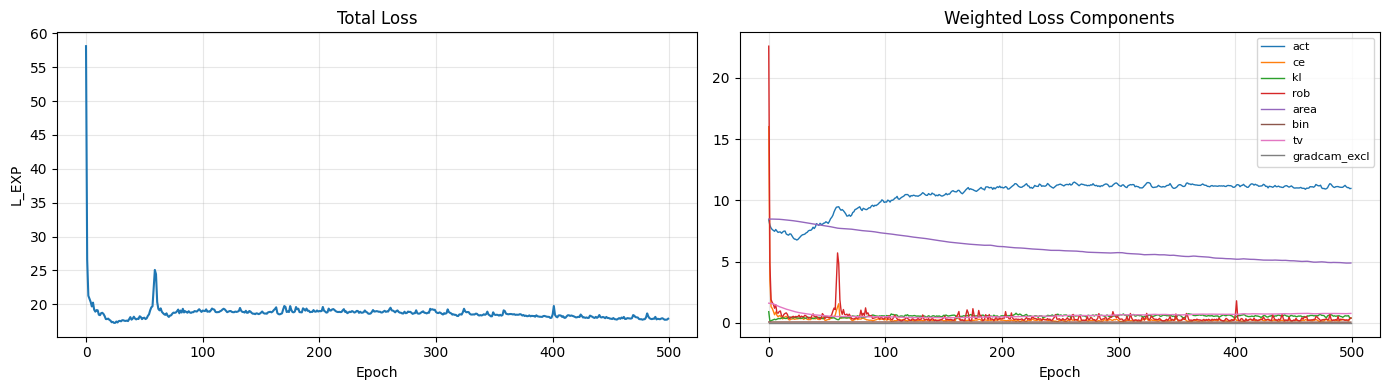

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Total loss
axes[0].plot([h["total"] for h in loss_history], linewidth=1.5)
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("L_EXP")
axes[0].grid(True, alpha=0.3)

def _weighted_components(h):
    # Compatibility: older runs may store raw components, newer runs may already store weighted ones.
    gradcam_excl_value = h.get("gradcam_excl", 0.0)
    raw_sum = (
        h["act"] + h["ce"] + h["kl"] + h["rob"] + h["area"] +
        h["bin"] + h["tv"] + h.get("area_e", 0.0) + h.get("tv_e", 0.0) + gradcam_excl_value
    )
    weighted_sum = (
        lambda_act * h["act"] + lambda_CE * h["ce"] + lambda_KL * h["kl"] +
        lambda_rob * h["rob"] + h["area"] + lambda_bin * h["bin"] +
        lambda_tv * h["tv"] +
        lambda_gradcam_excl * gradcam_excl_value
    )

    if abs(raw_sum - h["total"]) <= abs(weighted_sum - h["total"]):
        return {
            "act": h["act"],
            "ce": h["ce"],
            "kl": h["kl"],
            "rob": h["rob"],
            "area": h["area"],
            "bin": h["bin"],
            "tv": h["tv"],
            "gradcam_excl": gradcam_excl_value,
        }

    return {
        "act": lambda_act * h["act"],
        "ce": lambda_CE * h["ce"],
        "kl": lambda_KL * h["kl"],
        "rob": lambda_rob * h["rob"],
        "area": h["area"],
        "bin": lambda_bin * h["bin"],
        "tv": lambda_tv * h["tv"],
        "gradcam_excl": lambda_gradcam_excl * gradcam_excl_value,
    }

weighted_history = [_weighted_components(h) for h in loss_history]

# Weighted individual components
for key in ["act", "ce", "kl", "rob", "area", "bin", "tv", "gradcam_excl"]:
    axes[1].plot([h[key] for h in weighted_history], label=key, linewidth=1)
axes[1].set_title("Weighted Loss Components")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curves.png", dpi=100, bbox_inches="tight")
print(f"Saved loss curves to {OUTPUT_DIR}/loss_curves.png")
plt.show()


## Cell 10b — Pareto Sweep: Confidence vs Sparsity

Sweep `lambda_area_pixel` across a log-spaced range and plot the Pareto frontier of confidence (faithfulness) vs sparsity. Set `PARETO_EPOCHS` to an integer before running to use fewer training steps than the full config value.

In [11]:
# # ── Pareto Sweep: Confidence vs Sparsity ──────────────────────────────────────
# PARETO_LAMBDAS = [2500, 6000, 10000, 15000, 20000]
# if "PARETO_EPOCHS" not in dir():
#     PARETO_EPOCHS = epochs

# _pareto_lambda_orig = config.get("lambda_area_pixel", 1.0)
# _pareto_results = []  # list of (lam, sparsity, confidence)

# # Determine sweep image
# if single_image_mode:
#     _sweep_x = fixed_x
#     _sweep_y = fixed_y
# else:
#     _sweep_x_b, _sweep_y_b = next(iter(dataloader))
#     _sweep_x = _sweep_x_b[:1].to(DEVICE)
#     _sweep_y = _sweep_y_b[:1].to(DEVICE)

# # Predicted class from original image (fixed across sweep for consistent confidence)
# with torch.no_grad():
#     _logits_x0 = classifier(_sweep_x)
#     _top_class = int(_logits_x0.argmax(dim=1)[0].item())

# for _lam in PARETO_LAMBDAS:
#     lambda_area_pixel = _lam
#     reset_explainer_and_optimizer()

#     for _ in range(PARETO_EPOCHS):
#         train_step(_sweep_x, _sweep_y)

#     with torch.no_grad():
#         unet.eval()
#         _m_LL, _m_LH, _m_HL, _m_HH, _cont = unet(_sweep_x)
#         _e = construct_explanation(_sweep_x, _m_LL, _m_LH, _m_HL, _m_HH, _cont)
#         _probs = torch.softmax(classifier(_e), dim=1)
#         _confidence = _probs[0, _top_class].item()
#         _sparsity = m_LL.float().mean().item()

#     _pareto_results.append((_lam, _sparsity, _confidence))
#     print(f"lambda_area_pixel={_lam:<6d}  sparsity={_sparsity:.3f}  confidence={_confidence:.3f}")

# # Restore original state
# lambda_area_pixel = _pareto_lambda_orig
# reset_explainer_and_optimizer()

# # ── Pareto Frontier ────────────────────────────────────────────────────────────
# def _is_pareto_optimal(idx, results):
#     s_i, c_i = results[idx][1], results[idx][2]
#     return not any(
#         results[j][1] < s_i and results[j][2] > c_i
#         for j in range(len(results)) if j != idx
#     )

# _frontier_pts = sorted(
#     [(_pareto_results[i][1], _pareto_results[i][2], _pareto_results[i][0])
#      for i in range(len(_pareto_results))
#      if _is_pareto_optimal(i, _pareto_results)],
#     key=lambda t: t[0]
# )

# # ── Plot ───────────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(8, 5))

# for _lam, _sp, _co in _pareto_results:
#     ax.scatter(_sp, _co, s=60, color="steelblue", zorder=3)
#     ax.annotate(str(_lam), (_sp, _co), textcoords="offset points", xytext=(5, 4), fontsize=8)

# if _frontier_pts:
#     _fx = [t[0] for t in _frontier_pts]
#     _fy = [t[1] for t in _frontier_pts]
#     ax.step(_fx, _fy, where="post", color="tomato", linewidth=1.5, label="Pareto frontier", zorder=2)
#     ax.scatter(_fx, _fy, color="tomato", s=60, zorder=4)
#     ax.legend(fontsize=9)

# ax.set_xlabel("Sparsity  (pixel mask activity)")
# ax.set_ylabel("Confidence  (top-1 softmax probability)")
# ax.set_title("Confidence–Sparsity Pareto Curve")
# ax.grid(True, alpha=0.3)
# plt.tight_layout()

# _pareto_path = f"{OUTPUT_DIR}/pareto_curve.png"
# plt.savefig(_pareto_path, dpi=100, bbox_inches="tight")
# print(f"Saved Pareto curve to {_pareto_path}")
# plt.show()

## Cell 11 — Visualize Explanation + Grad-CAM

In standard mode, this visualizes one sample explanation and a Grad-CAM baseline.
In image-list retrain mode, it also saves final explanation and Grad-CAM images for each processed image into that image's output folder.

In [ ]:
def denorm(tensor):
    """Reverse normalization for display."""
    t = tensor.clone().cpu()
    if dataset_name in ("imagenet", "imagefolder", "stl10"):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        t = t * std + mean
    elif dataset_name == "mnist":
        t = t * 0.3081 + 0.1307
    return t.clamp(0, 1)


def to_numpy(t):
    """(C, H, W) tensor -> displayable numpy array."""
    t = t.detach().cpu().float()
    if t.ndim == 3 and t.shape[0] == 3:
        return np.clip(t.permute(1, 2, 0).numpy(), 0, 1)
    elif t.ndim == 3 and t.shape[0] == 1:
        return np.clip(t.squeeze(0).numpy(), 0, 1)
    return np.clip(t.numpy(), 0, 1)


def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


def _save_explanation_figure(m_LL_local, m_LH_local, m_HL_local, m_HH_local, x_disp_local, e_disp_local, save_path, best_epoch=None):
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    mode_title = "Pixel" if pixel_mask_mode else "Wavelet"
    if best_epoch is None:
        fig.suptitle(f"{mode_title} Explanation", fontsize=12, fontweight="bold")
    else:
        fig.suptitle(f"{mode_title} Explanation (Window-Best Epoch {best_epoch})", fontsize=12, fontweight="bold")

    # Row 1: Original
    for ax in axes[0]:
        ax.set_visible(False)
    ax_orig = fig.add_subplot(3, 1, 1)
    ax_orig.imshow(to_numpy(x_disp_local[0]))
    ax_orig.set_title("Original Image", fontsize=10)
    ax_orig.axis("off")

    # Row 2: Masks
    if pixel_mask_mode:
        axes[1][0].imshow(to_numpy(m_LL_local[0]), cmap="gray")
        axes[1][0].set_title("Pixel Mask", fontsize=9)
        axes[1][0].axis("off")
        for col in [1, 2, 3]:
            axes[1][col].axis("off")
    else:
        for col, (mask, title) in enumerate([
            (m_LL_local, "LL (Coarse)"), (m_LH_local, "LH (Horiz. Edges)"),
            (m_HL_local, "HL (Vert. Edges)"), (m_HH_local, "HH (Texture)")
        ]):
            axes[1][col].imshow(to_numpy(mask[0]), cmap="gray")
            axes[1][col].set_title(title, fontsize=9)
            axes[1][col].axis("off")

    # Row 3: Explanation
    for ax in axes[2]:
        ax.set_visible(False)
    ax_exp = fig.add_subplot(3, 1, 3)
    ax_exp.imshow(to_numpy(e_disp_local[0]))
    if pixel_mask_mode:
        if pixel_blur_mode:
            ax_exp.set_title("Explanation  e = m·x + (1-m)·blur(x)", fontsize=10)
        else:
            ax_exp.set_title("Explanation  e = m * x", fontsize=10)
    else:
        ax_exp.set_title("Explanation  e = IDWT(m * DWT(x))", fontsize=10)
    ax_exp.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.close()


def _find_last_conv_layer(model):
    for module in reversed(list(model.modules())):
        if isinstance(module, nn.Conv2d):
            return module
    return None


GRADCAM_TARGET_LAYER = _find_last_conv_layer(classifier)
if GRADCAM_TARGET_LAYER is None:
    print("Warning: No Conv2d layer found in classifier; Grad-CAM visualization will be skipped.")
else:
    print(f"Grad-CAM target layer: {GRADCAM_TARGET_LAYER.__class__.__name__}")


def _normalize_heatmap(cam):
    flat = cam.detach().float().view(cam.shape[0], -1)
    cam_min = flat.min(dim=1).values.view(-1, 1, 1, 1)
    cam_max = flat.max(dim=1).values.view(-1, 1, 1, 1)
    return ((cam - cam_min) / (cam_max - cam_min + 1e-8)).clamp(0.0, 1.0)


def compute_gradcam(x, target_idx=None):
    """Return Grad-CAM heatmap in [0, 1], shape (B, 1, H, W)."""
    if GRADCAM_TARGET_LAYER is None:
        return None, None, None

    acts, grads = [], []

    def _fwd_hook(module, inp, output):
        acts.append(output)

    def _bwd_hook(module, grad_input, grad_output):
        grads.append(grad_output[0])

    h_fwd = GRADCAM_TARGET_LAYER.register_forward_hook(_fwd_hook)
    h_bwd = GRADCAM_TARGET_LAYER.register_full_backward_hook(_bwd_hook)

    try:
        x_cam = x.detach().clone().to(DEVICE).requires_grad_(True)
        classifier.zero_grad(set_to_none=True)
        logits = classifier(x_cam)
        probs = torch.softmax(logits.detach(), dim=1)
        if target_idx is None:
            target_idx = logits.detach().argmax(dim=1)
        elif not torch.is_tensor(target_idx):
            target_idx = torch.tensor([int(target_idx)], device=x_cam.device).expand(x_cam.shape[0])
        else:
            target_idx = target_idx.to(x_cam.device).view(-1)

        score = logits.gather(1, target_idx.view(-1, 1)).sum()
        score.backward()

        if len(acts) == 0 or len(grads) == 0:
            return None, target_idx.detach(), probs

        weights = grads[0].mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts[0]).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x_cam.shape[-2:], mode="bilinear", align_corners=False)
        cam = _normalize_heatmap(cam).detach().cpu()
        classifier.zero_grad(set_to_none=True)
        return cam, target_idx.detach().cpu(), probs.detach().cpu()
    finally:
        h_fwd.remove()
        h_bwd.remove()


def _gradcam_overlay_rgb(image_chw, heatmap_hw, alpha=0.45):
    image = to_numpy(image_chw)
    heatmap = heatmap_hw.detach().cpu().float().numpy()
    cmap = plt.get_cmap("jet")(heatmap)[..., :3]
    return np.clip((1.0 - alpha) * image + alpha * cmap, 0.0, 1.0)


def _save_gradcam_figure(sample_x_local, x_disp_local, save_path, target_idx=None):
    cam, target_idx, probs = compute_gradcam(sample_x_local, target_idx=target_idx)
    if cam is None:
        print(f"Skipped Grad-CAM visualization: no target layer available for {save_path}")
        return None

    cls_id = int(target_idx[0].item())
    conf = float(probs[0, cls_id].item()) if probs is not None else float("nan")
    heatmap = cam[0, 0]
    overlay = _gradcam_overlay_rgb(x_disp_local[0], heatmap)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(to_numpy(x_disp_local[0]))
    axes[0].set_title("Original", fontsize=10)
    axes[0].axis("off")
    axes[1].imshow(heatmap.numpy(), cmap="jet", vmin=0.0, vmax=1.0)
    axes[1].set_title("Grad-CAM Heatmap", fontsize=10)
    axes[1].axis("off")
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay cls {cls_id} ({conf:.4f})", fontsize=10)
    axes[2].axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.close()
    print(f"Saved Grad-CAM visualization to {save_path}")
    return cam


# In per-image retrain mode, save final explanation for each image into its own folder.
image_list_mode = isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not single_image_mode)
retrain_per_image = bool(globals().get("RETRAIN_FROM_SCRATCH_PER_IMAGE", False)) and image_list_mode

if image_list_mode and retrain_per_image and ("dataset" in globals()):
    print("Saving one final explanation image per processed image...")
    saved_paths = []

    for img_idx in range(len(dataset)):
        image_name = dataset.image_names[img_idx] if hasattr(dataset, "image_names") else f"img_{img_idx}"
        image_stem = dataset.image_stems[img_idx] if hasattr(dataset, "image_stems") else os.path.splitext(os.path.basename(str(image_name)))[0]
        x_img, y_img = dataset[img_idx]
        y_label = int(y_img.item()) if torch.is_tensor(y_img) else int(y_img)
        effective_label = int(fixed_class_label) if fixed_class_label is not None else y_label
        image_folder_tag = _safe_output_tag(f"{image_stem}_cls{effective_label}")
        image_output_dir = os.path.join(BASE_OUTPUT_DIR, image_folder_tag)
        os.makedirs(image_output_dir, exist_ok=True)

        ckpt_path = os.path.join(image_output_dir, "wavelet_unet_checkpoint.pth")
        if not os.path.isfile(ckpt_path):
            print(f"Skipping {image_name}: checkpoint not found at {ckpt_path}")
            continue

        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        unet.load_state_dict(ckpt["encoder_decoder_state_dict"], strict=True)
        unet.eval()

        sample_x = x_img.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            m_LL, m_LH, m_HL, m_HH, cont_masks_viz = unet(sample_x)
            e = construct_explanation(sample_x, m_LL, m_LH, m_HL, m_HH, cont_masks_viz)
            
            probs_viz = torch.softmax(classifier(e), dim=1)
            top_conf_tensor, top_class_tensor = probs_viz[0].max(dim=0)
            top_class_for_viz = int(top_class_tensor.item())
            top_conf_for_viz = float(top_conf_tensor.item())

        x_disp = denorm(sample_x)
        e_disp = denorm(e)

        save_path = f"{image_output_dir}/explanation_final_cls{int(top_class_for_viz)}_conf{float(top_conf_for_viz):.4f}.png"
        _save_explanation_figure(m_LL, m_LH, m_HL, m_HH, x_disp, e_disp, save_path, best_epoch=None)
        saved_paths.append(save_path)
        print(f"Saved explanation to {save_path}")

        gradcam_path = f"{image_output_dir}/gradcam_final.png"
        _save_gradcam_figure(sample_x, x_disp, gradcam_path,
                             target_idx=int(fixed_class_label) if fixed_class_label is not None else None)

    if len(saved_paths) == 0:
        print("No per-image final explanations were saved.")
    else:
        print(f"Saved {len(saved_paths)} per-image final explanations.")

else:
    # Standard single-output behavior (single-image mode or non-retrain mode).
    # Prefer best-in-window snapshot from Cell 9, fallback to fresh inference.
    if "latest_best_snapshot" in globals() and latest_best_snapshot is not None:
        m_LL = latest_best_snapshot["m_LL"]
        m_LH = latest_best_snapshot["m_LH"]
        m_HL = latest_best_snapshot["m_HL"]
        m_HH = latest_best_snapshot["m_HH"]
        sample_x = latest_best_snapshot["sample_x"].to(DEVICE)
        x_disp = latest_best_snapshot["x_denorm"]
        e_disp = latest_best_snapshot["e_denorm"]
        best_epoch_for_viz = latest_best_snapshot["epoch"]
        top_class_for_viz = latest_best_snapshot.get("top_class", None)
        top_conf_for_viz = latest_best_snapshot.get("top_conf", None)
    else:
        if single_image_mode:
            sample_x = fixed_x
        else:
            sample_x, _ = next(iter(dataloader))
            sample_x = sample_x[:1].to(DEVICE)

        unet.eval()
        with torch.no_grad():
            m_LL, m_LH, m_HL, m_HH, cont_masks_viz = unet(sample_x)
            e = construct_explanation(sample_x, m_LL, m_LH, m_HL, m_HH, cont_masks_viz)
            probs_viz = torch.softmax(classifier(e), dim=1)
            top_conf_tensor, top_class_tensor = probs_viz[0].max(dim=0)
            top_class_for_viz = int(top_class_tensor.item())
            top_conf_for_viz = float(top_conf_tensor.item())

        x_disp = denorm(sample_x)
        e_disp = denorm(e)
        best_epoch_for_viz = None

    if top_class_for_viz is not None and top_conf_for_viz is not None:
        save_path = f"{OUTPUT_DIR}/explanation_final_cls{int(top_class_for_viz)}_conf{float(top_conf_for_viz):.4f}.png"
    else:
        save_path = f"{OUTPUT_DIR}/explanation_final.png"

    _save_explanation_figure(m_LL, m_LH, m_HL, m_HH, x_disp, e_disp, save_path, best_epoch=best_epoch_for_viz)
    print(f"Saved explanation to {save_path}")

    gradcam_path = f"{OUTPUT_DIR}/gradcam_final.png"
    gradcam_cam = _save_gradcam_figure(sample_x, x_disp, gradcam_path,
                                       target_idx=int(fixed_class_label) if fixed_class_label is not None else None)

    # Keep display output in standard mode.
    if gradcam_cam is None:
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
        ax.imshow(to_numpy(e_disp[0]))
        ax.set_title("Final Explanation Preview")
        ax.axis("off")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(to_numpy(e_disp[0]))
        axes[0].set_title("Final Explanation Preview")
        axes[0].axis("off")
        axes[1].imshow(_gradcam_overlay_rgb(x_disp[0], gradcam_cam[0, 0]))
        axes[1].set_title("Grad-CAM Preview")
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()

Grad-CAM target layer: Conv2d
Saving one final explanation image per processed image...
Saved explanation to my_exp_cam/outputs/resnet18_imagenet_single/egyptian_cat_cls285/explanation_final_cls285_conf0.9573.png
Saved Grad-CAM visualization to my_exp_cam/outputs/resnet18_imagenet_single/egyptian_cat_cls285/gradcam_final.png
Saved 1 per-image final explanations.


## Cell 12 — Subband Attribution Map

Colour-coded visualization showing which frequency content each pixel's explanation came from:
- **Cyan** = LL (coarse structure)
- **Green** = LH (horizontal edges)
- **Red** = HL (vertical edges)
- **Yellow** = HH (fine texture)

Saved subband attribution to my_exp_cam/outputs/resnet18_imagenet_single/egyptian_cat_cls285/subband_attribution.png


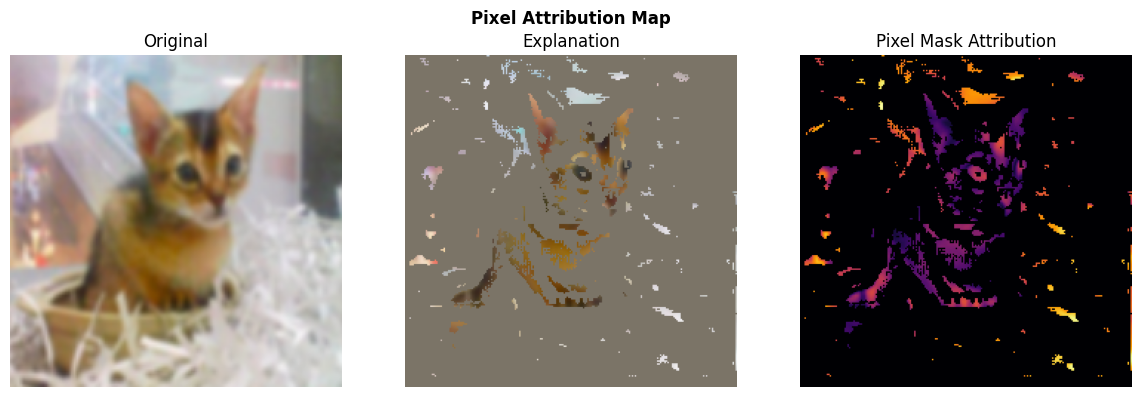

In [13]:
# Use masks and explanation from previous cell
x0 = x_disp[0].cpu().float()   # (C, H, W)
e0 = e_disp[0].cpu().float()
H, W = x0.shape[-2], x0.shape[-1]

# Upsample masks to full resolution
def _up(m):
    return F.interpolate(m[:1].cpu().float(), size=(H, W), mode="nearest").squeeze(0)  # (1, H, W)

m_up = {"LL": _up(m_LL), "LH": _up(m_LH), "HL": _up(m_HL), "HH": _up(m_HH)}

# Activity map: deviation from median (ignores uniform grey background)
baseline_val = e0.reshape(e0.shape[0], -1).median(dim=1).values.view(e0.shape[0], 1, 1)
e_activity = (e0 - baseline_val).abs().mean(dim=0)
e_activity = e_activity / (e_activity.max() + 1e-6)
e_activity = torch.where(e_activity >= 0.05, e_activity, torch.zeros_like(e_activity))

if pixel_mask_mode:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle("Pixel Attribution Map", fontsize=12, fontweight="bold")

    axes[0].imshow(to_numpy(x0))
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(to_numpy(e0))
    axes[1].set_title("Explanation")
    axes[1].axis("off")

    pixel_panel = (m_up["LL"].squeeze(0) * e_activity).numpy()
    axes[2].imshow(pixel_panel, cmap="inferno", vmin=0.0, vmax=1.0)
    axes[2].set_title("Pixel Mask Attribution")
    axes[2].axis("off")

else:
    subband_info = [
        ("LL", m_up["LL"], [0.0, 0.9, 0.9], "LL - coarse (cyan)"),
        ("LH", m_up["LH"], [0.2, 0.8, 0.3], "LH - horiz. edges (green)"),
        ("HL", m_up["HL"], [0.9, 0.2, 0.2], "HL - vert. edges (red)"),
        ("HH", m_up["HH"], [0.95, 0.85, 0.1], "HH - texture (yellow)"),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Subband Attribution Map", fontsize=12, fontweight="bold")

    # Row 1: Original + Explanation + individual subband panels
    axes[0][0].imshow(to_numpy(x0))
    axes[0][0].set_title("Original")
    axes[0][0].axis("off")
    axes[0][1].imshow(to_numpy(e0))
    axes[0][1].set_title("Explanation")
    axes[0][1].axis("off")
    axes[0][2].axis("off")
    axes[0][3].axis("off")

    # Row 2: Per-subband colour maps
    for col, (name, mask_up, colour, title) in enumerate(subband_info):
        c = torch.tensor(colour).view(3, 1, 1)
        panel = (c * mask_up * e_activity.unsqueeze(0)).permute(1, 2, 0).numpy()
        axes[1][col].imshow(np.clip(panel, 0, 1))
        axes[1][col].set_title(title, fontsize=9)
        axes[1][col].axis("off")

plt.tight_layout()
save_path = f"{OUTPUT_DIR}/subband_attribution.png"
plt.savefig(save_path, dpi=100, bbox_inches="tight")
print(f"Saved subband attribution to {save_path}")
plt.show()


## Cell 13 — Evaluation Metrics (Per-Image + GradCAM + Averages)

For each processed image, this cell computes the same comparison metrics for:
- **Your method** (wavelet/pixel explainer output)
- **GradCAM** baseline

Outputs saved by this cell:
- Per-image JSON metrics file in each image output folder
- Per-image bar chart comparing your method vs GradCAM
- Aggregate summary JSON with averages across all images
- Aggregate average bar chart for easy method comparison

In [14]:
import json
import math

ins_del_steps = int(config.get("ins_del_steps", 25))
metrics_curve_max_samples = int(config.get("metrics_curve_max_samples", 4))


def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


def _normalize_mask(mask):
    """Normalize each sample in a mask batch to [0, 1]."""
    m = mask.detach().float()
    flat = m.view(m.shape[0], -1)
    m_min = flat.min(dim=1).values.view(-1, 1, 1, 1)
    m_max = flat.max(dim=1).values.view(-1, 1, 1, 1)
    return ((m - m_min) / (m_max - m_min + 1e-8)).clamp(0.0, 1.0)


def _auc01(curve):
    xs = torch.linspace(0.0, 1.0, steps=curve.numel(), device=curve.device, dtype=curve.dtype)
    return float(torch.trapz(curve, xs).item())


def _pixel_ins_del_auc(xi, score_map, class_idx, n_steps=25):
    """Insertion/Deletion AUC for one sample in pixel space, baseline x0=0."""
    _, H, W = xi.shape
    total = H * W
    ranked = torch.argsort(score_map.reshape(-1), descending=True)

    base = torch.zeros_like(xi)
    ins_vals, del_vals = [], []

    for step in range(n_steps + 1):
        k = int(round((step / float(n_steps)) * total))
        mask_flat = torch.zeros(total, device=xi.device, dtype=xi.dtype)
        if k > 0:
            mask_flat[ranked[:k]] = 1.0
        mask = mask_flat.view(1, H, W)

        x_ins = base + xi * mask
        x_del = xi * (1.0 - mask)

        with torch.no_grad():
            p_ins = F.softmax(classifier(x_ins.unsqueeze(0)), dim=1)[0, class_idx]
            p_del = F.softmax(classifier(x_del.unsqueeze(0)), dim=1)[0, class_idx]
        ins_vals.append(p_ins)
        del_vals.append(p_del)

    ins_curve = torch.stack(ins_vals)
    del_curve = torch.stack(del_vals)
    return _auc01(ins_curve), _auc01(del_curve)


def _compute_faithfulness_metrics(x, logits_x, pred_x, mask_soft):
    mask_soft = mask_soft.clamp(0.0, 1.0)
    if mask_soft.shape[1] != 1:
        mask_soft = mask_soft.mean(dim=1, keepdim=True)

    with torch.no_grad():
        pred_in = classifier(x * mask_soft).argmax(dim=1)
        logits_masked_out = classifier(x * (1.0 - mask_soft))

    fid_in = float((pred_in == pred_x).float().mean().item())

    fx_c = logits_x.gather(1, pred_x.unsqueeze(1)).squeeze(1)
    fx_masked_out_c = logits_masked_out.gather(1, pred_x.unsqueeze(1)).squeeze(1)
    ff_median = float((fx_c - fx_masked_out_c).median().item())

    n_curve = min(x.shape[0], max(1, metrics_curve_max_samples))
    ins_scores, del_scores = [], []
    for i in range(n_curve):
        ins_auc_i, del_auc_i = _pixel_ins_del_auc(
            x[i],
            mask_soft[i, 0],
            int(pred_x[i].item()),
            n_steps=ins_del_steps,
        )
        ins_scores.append(ins_auc_i)
        del_scores.append(del_auc_i)

    insertion_auc = float(np.mean(ins_scores))
    deletion_auc = float(np.mean(del_scores))

    return {
        "fid_in": fid_in,
        "ff_median": ff_median,
        "insertion_auc": insertion_auc,
        "deletion_auc": deletion_auc,
    }


def _pearson_coherency(mask_a, mask_b):
    """Pearson coherency between two mask batches, normalized from [-1, 1] to [0, 1]."""
    if mask_b is None:
        return float("nan")
    if mask_a.shape[1] != 1:
        mask_a = mask_a.mean(dim=1, keepdim=True)
    if mask_b.shape[1] != 1:
        mask_b = mask_b.mean(dim=1, keepdim=True)
    mask_a = mask_a.detach().float().clamp(0.0, 1.0)
    mask_b = mask_b.detach().float().clamp(0.0, 1.0)
    if mask_a.shape[-2:] != mask_b.shape[-2:]:
        mask_b = F.interpolate(mask_b, size=mask_a.shape[-2:], mode="bilinear", align_corners=False)

    a = mask_a.flatten(1)
    b = mask_b.flatten(1)
    a = a - a.mean(dim=1, keepdim=True)
    b = b - b.mean(dim=1, keepdim=True)
    denom = a.norm(dim=1) * b.norm(dim=1)
    corr = torch.where(denom > 1e-8, (a * b).sum(dim=1) / denom.clamp(min=1e-8), torch.zeros_like(denom))
    return float(((corr.clamp(-1.0, 1.0) + 1.0) * 0.5).mean().item())


def _adcc_score(ad, comp, coh):
    """ADCC = harmonic mean of coherency, 1 - complexity, and 1 - average drop."""
    if not all(math.isfinite(float(v)) for v in [ad, comp, coh]):
        return float("nan")
    terms = [
        max(float(coh), 0.0),
        max(1.0 - float(comp), 0.0),
        max(1.0 - float(ad), 0.0),
    ]
    if any(v <= 0.0 for v in terms):
        return 0.0
    return 3.0 / sum(1.0 / v for v in terms)


def _compute_shared_metrics(x, logits_x, logits_e, mask_soft, mask_recompute_fn=None, explanation=None):
    pred_x = logits_x.argmax(dim=1)
    pred_e = logits_e.argmax(dim=1)
    label_pres = float((pred_x == pred_e).float().mean().item())

    prob_x = F.softmax(logits_x, dim=1)
    prob_e = F.softmax(logits_e, dim=1)
    conf_x = prob_x[torch.arange(len(pred_x), device=x.device), pred_x]
    conf_e = prob_e[torch.arange(len(pred_x), device=x.device), pred_x]
    conf_delta = float((conf_e - conf_x).mean().item())

    if mask_soft.shape[1] != 1:
        mask_soft = mask_soft.mean(dim=1, keepdim=True)
    mask_soft = mask_soft.clamp(0.0, 1.0)

    activity = float(mask_soft.mean().item())
    sparsity = float(1.0 - activity)
    average_drop_value = float(((conf_x - conf_e) / conf_x.clamp(min=1e-8)).mean().item())
    complexity_value = activity

    if explanation is None:
        explanation = x * mask_soft
    if mask_recompute_fn is None:
        coherency_value = float("nan")
    else:
        mask_on_explanation = mask_recompute_fn(explanation.detach(), pred_x.detach())
        coherency_value = _pearson_coherency(mask_soft, mask_on_explanation)
    adcc_value = _adcc_score(average_drop_value, complexity_value, coherency_value)

    faith = _compute_faithfulness_metrics(x, logits_x, pred_x, mask_soft)

    out = {
        "label_preservation": label_pres,
        "confidence_delta": conf_delta,
        "activity": activity,
        "sparsity": sparsity,
        "target_confidence_original": float(conf_x.mean().item()),
        "target_confidence_explanation": float(conf_e.mean().item()),
        "average_drop": average_drop_value,
        "complexity": complexity_value,
        "coherency": coherency_value,
        "adcc": adcc_value,
        "adcc_loss": float(1.0 - adcc_value) if math.isfinite(float(adcc_value)) else float("nan"),
    }
    out.update(faith)
    return out


def _find_last_conv_layer(model):
    for module in reversed(list(model.modules())):
        if isinstance(module, nn.Conv2d):
            return module
    return None


GRADCAM_TARGET_LAYER = _find_last_conv_layer(classifier)
if GRADCAM_TARGET_LAYER is None:
    print("Warning: No Conv2d layer found in classifier; GradCAM metrics will be NaN.")
else:
    print(f"GradCAM target layer: {GRADCAM_TARGET_LAYER.__class__.__name__}")


def _compute_gradcam_mask(x, target_idx):
    """Return GradCAM mask normalized to [0, 1], shape (B, 1, H, W)."""
    if GRADCAM_TARGET_LAYER is None:
        return None

    acts, grads = [], []

    def _fwd_hook(module, inp, output):
        acts.append(output)

    def _bwd_hook(module, grad_input, grad_output):
        grads.append(grad_output[0])

    h_fwd = GRADCAM_TARGET_LAYER.register_forward_hook(_fwd_hook)
    h_bwd = GRADCAM_TARGET_LAYER.register_full_backward_hook(_bwd_hook)

    try:
        x_cam = x.detach().clone().requires_grad_(True)
        classifier.zero_grad(set_to_none=True)
        logits = classifier(x_cam)
        score = logits.gather(1, target_idx.view(-1, 1)).sum()
        score.backward()

        if len(acts) == 0 or len(grads) == 0:
            return None

        a = acts[0]
        g = grads[0]
        weights = g.mean(dim=(2, 3), keepdim=True)
        cam = (weights * a).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x_cam.shape[-2:], mode="bilinear", align_corners=False)
        cam = _normalize_mask(cam).detach()

        classifier.zero_grad(set_to_none=True)
        return cam
    finally:
        h_fwd.remove()
        h_bwd.remove()


def _evaluate_methods_on_batch(eval_x):
    unet.eval()
    classifier.eval()

    with torch.no_grad():
        logits_x = classifier(eval_x)
        m_LL, m_LH, m_HL, m_HH, cont_masks_eval = unet(eval_x)
        e_method = construct_explanation(eval_x, m_LL, m_LH, m_HL, m_HH, cont_masks_eval)
        logits_method = classifier(e_method)

    # Build one comparable soft mask for your method.
    if pixel_mask_mode:
        method_mask = cont_masks_eval[0].detach()
        if method_mask.shape[1] != 1:
            method_mask = method_mask.mean(dim=1, keepdim=True)
        method_mask = _normalize_mask(method_mask)
    else:
        sb_soft = torch.stack([
            cont_masks_eval[0].detach(),
            cont_masks_eval[1].detach(),
            cont_masks_eval[2].detach(),
            cont_masks_eval[3].detach(),
        ], dim=0).mean(dim=0)
        method_mask = F.interpolate(sb_soft, size=eval_x.shape[-2:], mode="nearest")
        method_mask = _normalize_mask(method_mask)

    def _method_mask_recompute(imgs, labels):
        with torch.no_grad():
            r_LL, r_LH, r_HL, r_HH, r_cont = unet(imgs)
            if pixel_mask_mode:
                r_mask = r_cont[0].detach()
                if r_mask.shape[1] != 1:
                    r_mask = r_mask.mean(dim=1, keepdim=True)
                return _normalize_mask(r_mask)
            r_sb = torch.stack([
                r_cont[0].detach(), r_cont[1].detach(),
                r_cont[2].detach(), r_cont[3].detach(),
            ], dim=0).mean(dim=0)
            r_mask = F.interpolate(r_sb, size=imgs.shape[-2:], mode="nearest")
            return _normalize_mask(r_mask)

    method_metrics = _compute_shared_metrics(
        eval_x, logits_x, logits_method, method_mask,
        mask_recompute_fn=_method_mask_recompute,
        explanation=e_method,
    )

    if pixel_mask_mode:
        method_metrics["pixel_activity"] = float(m_LL.float().mean().item())
        method_metrics["pixel_sparsity"] = float(1.0 - m_LL.float().mean().item())
    else:
        method_metrics["LL_activity"] = float(m_LL.float().mean().item())
        method_metrics["LH_activity"] = float(m_LH.float().mean().item())
        method_metrics["HL_activity"] = float(m_HL.float().mean().item())
        method_metrics["HH_activity"] = float(m_HH.float().mean().item())
        method_metrics["LL_sparsity"] = float(1.0 - m_LL.float().mean().item())
        method_metrics["LH_sparsity"] = float(1.0 - m_LH.float().mean().item())
        method_metrics["HL_sparsity"] = float(1.0 - m_HL.float().mean().item())
        method_metrics["HH_sparsity"] = float(1.0 - m_HH.float().mean().item())

    pred_x = (torch.full((eval_x.shape[0],), int(fixed_class_label), dtype=torch.long, device=eval_x.device)
              if fixed_class_label is not None else logits_x.argmax(dim=1).detach())
    cam_mask = _compute_gradcam_mask(eval_x, pred_x)

    if cam_mask is None:
        gradcam_metrics = {
            "label_preservation": float("nan"),
            "confidence_delta": float("nan"),
            "activity": float("nan"),
            "sparsity": float("nan"),
            "target_confidence_original": float("nan"),
            "target_confidence_explanation": float("nan"),
            "average_drop": float("nan"),
            "complexity": float("nan"),
            "coherency": float("nan"),
            "adcc": float("nan"),
            "adcc_loss": float("nan"),
            "fid_in": float("nan"),
            "ff_median": float("nan"),
            "insertion_auc": float("nan"),
            "deletion_auc": float("nan"),
        }
    else:
        with torch.no_grad():
            gradcam_expl = eval_x * cam_mask
            logits_gradcam = classifier(gradcam_expl)

        def _gradcam_mask_recompute(imgs, labels):
            return _compute_gradcam_mask(imgs, labels)

        gradcam_metrics = _compute_shared_metrics(
            eval_x, logits_x, logits_gradcam, cam_mask,
            mask_recompute_fn=_gradcam_mask_recompute,
            explanation=gradcam_expl,
        )

    return method_metrics, gradcam_metrics


def _is_number(x):
    return isinstance(x, (int, float, np.floating)) and math.isfinite(float(x))


def _average_metric_dict(metric_dicts):
    all_keys = sorted(set().union(*[d.keys() for d in metric_dicts])) if metric_dicts else []
    out = {}
    for key in all_keys:
        vals = [float(d[key]) for d in metric_dicts if key in d and _is_number(d[key])]
        if len(vals) > 0:
            out[key] = float(np.mean(vals))
    return out


def _write_json(path, payload):
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)


METRIC_PREFERENCE = {
    "label_preservation": "higher",
    "confidence_delta": "higher",
    "activity": "lower",
    "sparsity": "higher",
    "target_confidence_original": "higher",
    "target_confidence_explanation": "higher",
    "fid_in": "higher",
    "ff_median": "higher",
    "average_drop": "lower",
    "complexity": "lower",
    "coherency": "higher",
    "adcc": "higher",
    "adcc_loss": "lower",
    "insertion_auc": "higher",
    "deletion_auc": "lower",
    "LL_activity": "lower",
    "LH_activity": "lower",
    "HL_activity": "lower",
    "HH_activity": "lower",
    "LL_sparsity": "higher",
    "LH_sparsity": "higher",
    "HL_sparsity": "higher",
    "HH_sparsity": "higher",
    "pixel_activity": "lower",
    "pixel_sparsity": "higher",
}


def _metric_pref_suffix(metric_name):
    better = METRIC_PREFERENCE.get(metric_name, "higher")
    return "higher better" if better == "higher" else "lower better"


def _metric_label(metric_name):
    return f"{metric_name}\n({_metric_pref_suffix(metric_name)})"


def _plot_method_comparison_bar(method_metrics, gradcam_metrics, title, save_path):
    keys = sorted(set(method_metrics.keys()) | set(gradcam_metrics.keys()))
    keys = [k for k in keys if _is_number(method_metrics.get(k, float("nan"))) or _is_number(gradcam_metrics.get(k, float("nan")))]
    if len(keys) == 0:
        print(f"Skipping bar plot (no numeric metrics): {save_path}")
        return

    method_vals = [float(method_metrics.get(k, float("nan"))) for k in keys]
    gradcam_vals = [float(gradcam_metrics.get(k, float("nan"))) for k in keys]

    x = np.arange(len(keys))
    width = 0.38

    fig, ax = plt.subplots(figsize=(max(12, len(keys) * 0.8), 5))
    ax.bar(x - width / 2, method_vals, width, label="Your Method", color="#1f77b4")
    ax.bar(x + width / 2, gradcam_vals, width, label="GradCAM", color="#ff7f0e")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Metric Value")
    ax.set_xticks(x)
    metric_labels = [_metric_label(k) for k in keys]
    ax.set_xticklabels(metric_labels, rotation=45, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.close()
    print(f"Saved bar chart: {save_path}")


results = []
image_list_mode = isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not single_image_mode)
retrain_per_image = bool(globals().get("RETRAIN_FROM_SCRATCH_PER_IMAGE", False)) and image_list_mode

if image_list_mode:
    print("Evaluating per image (your method vs GradCAM)...")

    if "dataset" not in globals():
        raise RuntimeError("Expected image-list dataset to be initialized in Cell 7.")

    for img_idx in range(len(dataset)):
        image_name = dataset.image_names[img_idx] if hasattr(dataset, "image_names") else f"img_{img_idx}"
        image_stem = dataset.image_stems[img_idx] if hasattr(dataset, "image_stems") else os.path.splitext(os.path.basename(str(image_name)))[0]
        x_img, y_img = dataset[img_idx]
        y_label = int(y_img.item()) if torch.is_tensor(y_img) else int(y_img)
        effective_label = int(fixed_class_label) if fixed_class_label is not None else y_label
        image_folder_tag = _safe_output_tag(f"{image_stem}_cls{effective_label}")
        image_output_dir = os.path.join(BASE_OUTPUT_DIR, image_folder_tag)
        os.makedirs(image_output_dir, exist_ok=True)

        if retrain_per_image:
            ckpt_path = os.path.join(image_output_dir, "wavelet_unet_checkpoint.pth")
            if not os.path.isfile(ckpt_path):
                print(f"Warning: checkpoint missing for {image_name}: {ckpt_path}")
                continue
            ckpt = torch.load(ckpt_path, map_location=DEVICE)
            unet.load_state_dict(ckpt["encoder_decoder_state_dict"], strict=True)

        eval_x = x_img.unsqueeze(0).to(DEVICE)

        method_metrics, gradcam_metrics = _evaluate_methods_on_batch(eval_x)

        per_image_metrics_path = os.path.join(image_output_dir, "metrics_method_vs_gradcam.json")
        record = {
            "image_index": int(img_idx),
            "image_name": str(image_name),
            "output_dir": image_output_dir,
            "method": method_metrics,
            "gradcam": gradcam_metrics,
            "metrics_json_path": per_image_metrics_path,
        }
        results.append(record)

        _write_json(per_image_metrics_path, record)
        print(f"Saved per-image metrics: {per_image_metrics_path}")

        per_image_bar_path = os.path.join(image_output_dir, "metrics_method_vs_gradcam_bar.png")
        _plot_method_comparison_bar(
            method_metrics,
            gradcam_metrics,
            title=f"Method vs GradCAM ({image_stem})",
            save_path=per_image_bar_path,
        )

    if len(results) == 0:
        raise RuntimeError("No per-image metrics were generated.")

    method_avg = _average_metric_dict([r["method"] for r in results])
    gradcam_avg = _average_metric_dict([r["gradcam"] for r in results])

    summary_path = os.path.join(BASE_OUTPUT_DIR, "metrics_method_vs_gradcam_summary.json")
    summary = {
        "num_images": len(results),
        "method_average": method_avg,
        "gradcam_average": gradcam_avg,
        "per_image_results": results,
        "summary_json_path": summary_path,
    }

    _write_json(summary_path, summary)
    print(f"Saved average comparison summary: {summary_path}")

    avg_bar_path = os.path.join(BASE_OUTPUT_DIR, "metrics_method_vs_gradcam_average_bar.png")
    _plot_method_comparison_bar(
        method_avg,
        gradcam_avg,
        title="Average Metrics: Your Method vs GradCAM",
        save_path=avg_bar_path,
    )

    print("\n" + "=" * 60)
    print("AVERAGE METRICS ACROSS IMAGES")
    print("=" * 60)
    print("\nYour Method:")
    for k, v in method_avg.items():
        print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")
    print("\nGradCAM:")
    for k, v in gradcam_avg.items():
        print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")

else:
    # Non-image-list fallback: evaluate current mode once and still save comparison files.
    if single_image_mode:
        eval_x = fixed_x
    else:
        eval_x, _ = next(iter(dataloader))
        eval_x = eval_x.to(DEVICE)

    method_metrics, gradcam_metrics = _evaluate_methods_on_batch(eval_x)
    payload = {
        "num_images": int(eval_x.shape[0]),
        "method": method_metrics,
        "gradcam": gradcam_metrics,
    }

    fallback_json_path = os.path.join(OUTPUT_DIR, "metrics_method_vs_gradcam.json")
    _write_json(fallback_json_path, payload)
    print(f"Saved metrics comparison: {fallback_json_path}")

    fallback_bar_path = os.path.join(OUTPUT_DIR, "metrics_method_vs_gradcam_bar.png")
    _plot_method_comparison_bar(
        method_metrics,
        gradcam_metrics,
        title="Method vs GradCAM (Current Batch)",
        save_path=fallback_bar_path,
    )

    print("\n" + "=" * 50)
    print("EVALUATION METRICS (CURRENT BATCH)")
    print("=" * 50)
    print("\nYour Method:")
    for k, v in method_metrics.items():
        if _is_number(v):
            print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")
    print("\nGradCAM:")
    for k, v in gradcam_metrics.items():
        if _is_number(v):
            print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")

GradCAM target layer: Conv2d
Evaluating per image (your method vs GradCAM)...
Saved per-image metrics: my_exp_cam/outputs/resnet18_imagenet_single/egyptian_cat_cls285/metrics_method_vs_gradcam.json
Saved bar chart: my_exp_cam/outputs/resnet18_imagenet_single/egyptian_cat_cls285/metrics_method_vs_gradcam_bar.png
Saved average comparison summary: my_exp_cam/outputs/resnet18_imagenet_single/metrics_method_vs_gradcam_summary.json
Saved bar chart: my_exp_cam/outputs/resnet18_imagenet_single/metrics_method_vs_gradcam_average_bar.png

AVERAGE METRICS ACROSS IMAGES

Your Method:
                        activity (lower better): +0.327924
                            adcc (higher better): +0.713540
                       adcc_loss (lower better): +0.286460
                    average_drop (lower better): -1.117351
                       coherency (higher better): +0.445599
                      complexity (lower better): +0.327924
                confidence_delta (higher better): +0.505162
      

## Cell 14 — Save / Load Checkpoint

Save the trained U-Net weights for later use. Only the U-Net is saved (the classifier is frozen and never changes).

In [15]:
# CHECKPOINT_PATH = "wavelet_unet_checkpoint.pth"

# # Save
# torch.save({
#     "encoder_decoder_state_dict": unet.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "config": config,
# }, CHECKPOINT_PATH)
# print(f"Checkpoint saved to {CHECKPOINT_PATH}")

# # To load later:
# # ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
# # unet.load_state_dict(ckpt["encoder_decoder_state_dict"])
# # optimizer.load_state_dict(ckpt["optimizer_state_dict"])

## Cell 15 — ADCC Evaluation (Poppi et al. CVPRW 2021)

Implements Average Drop (AD), Complexity (COMP), Coherency (COH), ADCC, and IIC
for EXP-CAM vs Grad-CAM. All metrics computed from scratch with no external XAI libraries.

| Metric | Formula | Better |
|--------|---------|--------|
| AD | mean(max(0, p(y|x) - p(y|e)) / p(y|x)) | ↓ |
| IIC | fraction where p(y|e) > p(y|x) | ↑ |
| COMP | ‖cam‖₁ / (H·W) | ↓ |
| COH | PearsonCorr(cam(x), cam(e)) | ↑ |
| ADCC | HarmonicMean(COH, 1−COMP, 1−AD) | ↑ |

In [16]:
import math
import numpy as np
import torch
import torch.nn.functional as F


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — COMPONENT METRICS
# ══════════════════════════════════════════════════════════════════════════════

def average_drop(p_x_c, p_e_c):
    """
    Average Drop: mean relative confidence drop when x is replaced by explanation e.
    AD = mean((p(y|x) - p(y|e)) / p(y|x)); can be negative when explanation confidence increases
    Returns value in [0, 1]. Lower is better.
    Args:
        p_x_c: (B,) softmax prob of predicted class on original image x
        p_e_c: (B,) softmax prob of predicted class on explanation e
    """
    return ((p_x_c - p_e_c) / p_x_c.clamp(min=1e-8)).mean().item()


def complexity(cam):
    """
    Complexity: mean mask density = mean over batch of ( ||cam||_1 / (H * W) ).
    cam: (B, 1, H, W) in [0, 1]. Lower is better.
    """
    B, _, H, W = cam.shape
    return (cam.sum(dim=(1, 2, 3)) / (H * W)).mean().item()


def coherency(cam_x, cam_e):
    """Pearson coherency between CAM(x) and CAM(x * CAM(x)), normalized to [0, 1]."""
    if cam_e is None:
        return float("nan")
    if cam_x.shape[1] != 1:
        cam_x = cam_x.mean(dim=1, keepdim=True)
    if cam_e.shape[1] != 1:
        cam_e = cam_e.mean(dim=1, keepdim=True)
    cam_x = cam_x.detach().float().clamp(0.0, 1.0)
    cam_e = cam_e.detach().float().clamp(0.0, 1.0)
    if cam_x.shape[-2:] != cam_e.shape[-2:]:
        cam_e = F.interpolate(cam_e, size=cam_x.shape[-2:], mode="bilinear", align_corners=False)

    a = cam_x.flatten(1)
    b = cam_e.flatten(1)
    a = a - a.mean(dim=1, keepdim=True)
    b = b - b.mean(dim=1, keepdim=True)
    denom = a.norm(dim=1) * b.norm(dim=1)
    corr = torch.where(denom > 1e-8, (a * b).sum(dim=1) / denom.clamp(min=1e-8), torch.zeros_like(denom))
    return float(((corr.clamp(-1.0, 1.0) + 1.0) * 0.5).mean().item())


def adc_score(comp, ad):
    """ADC = HarmonicMean(1 - Complexity, 1 - AverageDrop)."""
    if not all(math.isfinite(float(v)) for v in [comp, ad]):
        return float("nan")
    terms = [
        max(1.0 - float(comp), 0.0),
        max(1.0 - float(ad), 0.0),
    ]
    if any(v <= 0.0 for v in terms):
        return 0.0
    return 2.0 / sum(1.0 / v for v in terms)


def adcc_score(comp, ad, coh):
    """ADCC = HarmonicMean(Coherency, 1 - Complexity, 1 - AverageDrop)."""
    if not all(math.isfinite(float(v)) for v in [comp, ad, coh]):
        return float("nan")
    terms = [
        max(float(coh), 0.0),
        max(1.0 - float(comp), 0.0),
        max(1.0 - float(ad), 0.0),
    ]
    if any(v <= 0.0 for v in terms):
        return 0.0
    return 3.0 / sum(1.0 / v for v in terms)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — MASK EXTRACTION FOR EACH METHOD
# ══════════════════════════════════════════════════════════════════════════════

# ── EXP-CAM ──────────────────────────────────────────────────────────────────

def _expcam_hard_mask(x):
    """
    Return binary (STE-binarised) mask in pixel space, shape (B, 1, H, W).
    In wavelet mode, subband masks are averaged, upsampled, then thresholded at 0.5.
    """
    unet.eval()
    with torch.no_grad():
        m_LL, m_LH, m_HL, m_HH, _ = unet(x)
        if pixel_mask_mode:
            hard = m_LL
            if hard.shape[1] != 1:
                hard = hard.mean(dim=1, keepdim=True)
        else:
            sb = torch.stack([m_LL, m_LH, m_HL, m_HH], dim=0).float().mean(dim=0)
            sb = F.interpolate(sb, size=x.shape[-2:], mode="nearest")
            if sb.shape[1] != 1:
                sb = sb.mean(dim=1, keepdim=True)
            hard = (sb >= 0.5).float()
    return hard


# ── Grad-CAM ─────────────────────────────────────────────────────────────────

def _gradcam_mask(x, pred, threshold=0.5):
    """
    Standard Grad-CAM: gradient of score w.r.t. last conv activations,
    globally pooled to get channel weights, then ReLU(weighted sum of activations).
    Normalised to [0,1] and hard-thresholded.
    Returns (B, 1, H, W) binary mask.
    """
    cam_raw, _, _ = compute_gradcam(x, target_idx=pred)   # existing helper
    if cam_raw is None:
        return None
    return (cam_raw >= threshold).float().to(x.device)


# ── Grad-CAM++ ───────────────────────────────────────────────────────────────

def _gradcamplusplus_mask(x, pred, target_layer, threshold=0.5):
    """
    Grad-CAM++: weights each channel by alpha_k^c = second-order gradient terms.
    alpha_k^c = grad^2 S^c / (2 * grad^2 S^c + sum_ab A_k * grad^3 S^c)
    where S^c is the class score (pre-softmax logit) for class c.
    Ref: Chattopadhyay et al., 2018.
    Returns (B, 1, H, W) binary mask.
    """
    B, C, H, W = x.shape
    activations, grads = {}, {}

    def fwd_hook(m, inp, out):
        activations["val"] = out.detach()
    def bwd_hook(m, gin, gout):
        grads["val"] = gout[0].detach()

    fh = target_layer.register_forward_hook(fwd_hook)
    bh = target_layer.register_full_backward_hook(bwd_hook)

    classifier.zero_grad()
    x_grad = x.detach().requires_grad_(True)   # ensure grad flows through input
    out = classifier(x_grad)
    score = out[torch.arange(B, device=x.device), pred].sum()
    score.backward()

    fh.remove(); bh.remove()

    A  = activations["val"]                        # (B, K, h, w)
    g  = grads["val"]                              # (B, K, h, w)
    g2 = g ** 2
    g3 = g ** 3
    denom = 2 * g2 + (A * g3).sum(dim=(2, 3), keepdim=True).clamp(min=1e-8)
    alpha = g2 / denom                             # (B, K, h, w)
    weights = (F.relu(g) * alpha).sum(dim=(2, 3)) # (B, K)

    cam = (weights[:, :, None, None] * A).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=(H, W), mode="bilinear", align_corners=False)
    # normalise per sample to [0, 1]
    cam_min = cam.flatten(1).min(1).values[:, None, None, None]
    cam_max = cam.flatten(1).max(1).values[:, None, None, None]
    cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
    return (cam >= threshold).float()


# ── Score-CAM ────────────────────────────────────────────────────────────────

def _scorecam_mask(x, pred, target_layer, threshold=0.5, max_channels=64):
    """
    Score-CAM: gradient-free CAM.
    Ref: Wang et al., CVPR Workshop 2020.

    Correct algorithm:
      w_k^c = S(x ⊙ H_k)_c  -  S(x_baseline)_c
    where H_k is the normalised, upsampled k-th activation channel and
    x_baseline is a zero image. The baseline subtraction removes the model's
    class prior — without it every channel inherits the prior confidence and
    the discriminative signal is diluted.

    max_channels: cap channel count to avoid OOM on wide layers.
    Returns (B, 1, H, W) binary mask.
    """
    B, C, H, W = x.shape
    activations = {}

    def fwd_hook(m, inp, out):
        activations["val"] = out.detach()

    fh = target_layer.register_forward_hook(fwd_hook)
    with torch.no_grad():
        classifier(x)
    fh.remove()

    A = activations["val"]                              # (B, K, h, w)
    K = A.shape[1]
    if K > max_channels:
        idx = torch.randperm(K)[:max_channels]
        A   = A[:, idx]
        K   = max_channels

    # upsample and normalise each channel map to [0, 1]
    A_up  = F.interpolate(A, size=(H, W), mode="bilinear", align_corners=False)
    a_min = A_up.flatten(2).min(-1).values[:, :, None, None]
    a_max = A_up.flatten(2).max(-1).values[:, :, None, None]
    A_norm = (A_up - a_min) / (a_max - a_min + 1e-8)   # (B, K, H, W)

    # baseline confidence on zero image (model class prior)
    with torch.no_grad():
        baseline      = torch.zeros_like(x)
        p_baseline    = F.softmax(classifier(baseline), dim=1)
        p_base_c      = p_baseline[torch.arange(B), pred]  # (B,)

    # per-channel confidence minus baseline
    weights = torch.zeros(B, K, device=x.device)
    with torch.no_grad():
        for k in range(K):
            masked   = x * A_norm[:, k:k+1]
            probs_k  = F.softmax(classifier(masked), dim=1)
            weights[:, k] = probs_k[torch.arange(B), pred] - p_base_c

    cam = (weights[:, :, None, None] * A_norm).sum(dim=1, keepdim=True)
    cam = F.relu(cam)                                   # keep only positive contributions
    cam_min = cam.flatten(1).min(1).values[:, None, None, None]
    cam_max = cam.flatten(1).max(1).values[:, None, None, None]
    cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
    return (cam >= threshold).float()


# ── Attention Maps (ViT only) ─────────────────────────────────────────────────

def _attention_mask(x, pred, vit_model, threshold=0.5):
    """
    Attention Maps from the last transformer block of a ViT.
    Averages attention weights across all heads for the [CLS] token.
    Reshapes patch-level attention to spatial map and upsamples to input size.
    Returns (B, 1, H, W) binary mask, or None if classifier is not a ViT.
    """
    B, C, H, W = x.shape
    attentions = {}

    try:
        # works for timm ViT and HuggingFace ViT
        last_block = list(vit_model.blocks)[-1]     # timm
    except AttributeError:
        try:
            last_block = list(vit_model.encoder.layer)[-1]   # HuggingFace
        except AttributeError:
            return None

    def attn_hook(m, inp, out):
        # out is typically (B, num_heads, seq_len, seq_len)
        if isinstance(out, tuple):
            attentions["val"] = out[0].detach()
        else:
            attentions["val"] = out.detach()

    fh = last_block.attn.register_forward_hook(attn_hook)
    with torch.no_grad():
        _ = vit_model(x)
    fh.remove()

    attn = attentions.get("val")
    if attn is None:
        return None

    # attn: (B, heads, seq_len, seq_len); CLS token attends to patches via row 0
    attn_cls = attn[:, :, 0, 1:]                   # (B, heads, num_patches)
    attn_cls = attn_cls.mean(dim=1)                 # (B, num_patches) — avg over heads

    n_patches = attn_cls.shape[1]
    patch_h = patch_w = int(n_patches ** 0.5)
    attn_map = attn_cls.reshape(B, 1, patch_h, patch_w)
    attn_map = F.interpolate(attn_map, size=(H, W), mode="bilinear", align_corners=False)

    a_min = attn_map.flatten(1).min(1).values[:, None, None, None]
    a_max = attn_map.flatten(1).max(1).values[:, None, None, None]
    attn_map = (attn_map - a_min) / (a_max - a_min + 1e-8)
    return (attn_map >= threshold).float()


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — GENERIC PER-BATCH METRIC COMPUTATION
# ══════════════════════════════════════════════════════════════════════════════

def _compute_metrics(x, pred, mask_fn, explanation_fn=None):
    """
    Generic per-batch metric computation given a mask-extraction function.

    Args:
        x          : (B, C, H, W) input batch on DEVICE
        pred       : (B,) predicted class indices
        mask_fn    : callable(x, pred) -> (B, 1, H, W) binary mask in [0,1],
                     or None on failure
        explanation_fn : optional callable(x, mask) -> (B, C, H, W) explanation.
                     Defaults to x * mask (pointwise multiplication).

    Returns dict with keys: ad, comp, coh, adcc, adcc_loss. Also keeps adc as an ADCC alias.
    """
    nan = float("nan")
    mask_x = mask_fn(x, pred)
    if mask_x is None:
        return {"ad": nan, "comp": nan, "coh": nan, "adcc": nan, "adcc_loss": nan, "adc": nan}

    # build explanation
    if explanation_fn is not None:
        e = explanation_fn(x, mask_x)
    else:
        e = x * mask_x                              # default: pointwise mask

    with torch.no_grad():
        logits_x = classifier(x)
        logits_e = classifier(e)

    probs_x = F.softmax(logits_x, dim=1)
    probs_e = F.softmax(logits_e, dim=1)
    p_x_c   = probs_x[torch.arange(len(pred), device=x.device), pred]
    p_e_c   = probs_e[torch.arange(len(pred), device=x.device), pred]

    ad   = average_drop(p_x_c, p_e_c)
    comp = complexity(mask_x)
    mask_e = mask_fn(e.detach(), pred)
    coh = coherency(mask_x, mask_e)
    adc = adc_score(comp, ad)
    adcc = adcc_score(comp, ad, coh)
    return {
        "ad": ad,
        "comp": comp,
        "coh": coh,
        "adc": adc,
        "adcc": adcc,
        "adcc_loss": float(1.0 - adcc) if math.isfinite(float(adcc)) else nan,
    }


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — METHOD-SPECIFIC WRAPPERS
# ══════════════════════════════════════════════════════════════════════════════

def _metrics_expcam(x, pred):
    """EXP-CAM: uses trained U-Net binary mask and construct_explanation."""
    def mask_fn(imgs, labels):
        return _expcam_hard_mask(imgs)

    def expl_fn(imgs, mask):
        unet.eval()
        with torch.no_grad():
            m_LL, m_LH, m_HL, m_HH, cont = unet(imgs)
            return construct_explanation(imgs, m_LL, m_LH, m_HL, m_HH, cont)

    return _compute_metrics(x, pred, mask_fn, explanation_fn=expl_fn)


def _metrics_gradcam(x, pred):
    """Grad-CAM: gradients of class score w.r.t. last conv activations."""
    def mask_fn(imgs, labels):
        return _gradcam_mask(imgs, labels, threshold=0.5)
    return _compute_metrics(x, pred, mask_fn)


def _metrics_gradcamplusplus(x, pred, target_layer):
    """Grad-CAM++: second-order gradient weights."""
    def mask_fn(imgs, labels):
        return _gradcamplusplus_mask(imgs, labels, target_layer, threshold=0.5)
    return _compute_metrics(x, pred, mask_fn)


def _metrics_scorecam(x, pred, target_layer):
    """Score-CAM: gradient-free, forward-pass channel scoring."""
    def mask_fn(imgs, labels):
        return _scorecam_mask(imgs, labels, target_layer, threshold=0.5)
    return _compute_metrics(x, pred, mask_fn)


def _metrics_attention(x, pred, vit_model):
    """Attention Maps: CLS-token attention from last ViT block."""
    def mask_fn(imgs, labels):
        return _attention_mask(imgs, labels, vit_model, threshold=0.5)
    return _compute_metrics(x, pred, mask_fn)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — EVALUATION LOOP
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_adc(
    dataloader,
    target_layer=None,      # required for GradCAM++ and Score-CAM
    vit_model=None,         # required for Attention Maps; pass None to skip
    n_batches=None,
    methods=("expcam", "gradcam", "gradcam++", "scorecam", "attention"),
):
    """
    Run ADC evaluation for all specified methods over batches from dataloader.

    Args:
        dataloader   : yields (x, y) batches
        target_layer : nn.Module — last conv layer of classifier
                       (required for gradcam++, scorecam)
        vit_model    : ViT model instance for attention map extraction
                       (pass None to skip attention maps)
        n_batches    : max batches to process (None = all)
        methods      : tuple of method names to evaluate

    Returns:
        dict with per-method list of batch dicts and mean dicts.
    """
    classifier.eval()
    records = {m: [] for m in methods}

    for batch_idx, (x_batch, _) in enumerate(dataloader):
        if n_batches is not None and batch_idx >= n_batches:
            break

        x_batch = x_batch.to(DEVICE)
        with torch.no_grad():
            logits_x = classifier(x_batch)

        pred = (
            torch.full((x_batch.shape[0],), int(fixed_class_label),
                       dtype=torch.long, device=DEVICE)
            if fixed_class_label is not None
            else logits_x.argmax(dim=1)
        )

        # skip samples where classifier is already at zero confidence
        probs_x = F.softmax(logits_x, dim=1)
        valid   = probs_x[torch.arange(len(pred)), pred] > 0
        if not valid.any():
            continue
        x_v, p_v = x_batch[valid], pred[valid]

        batch_results = {}

        if "expcam" in methods:
            batch_results["expcam"] = _metrics_expcam(x_v, p_v)

        if "gradcam" in methods:
            batch_results["gradcam"] = _metrics_gradcam(x_v, p_v)

        if "gradcam++" in methods and target_layer is not None:
            batch_results["gradcam++"] = _metrics_gradcamplusplus(x_v, p_v, target_layer)

        if "scorecam" in methods and target_layer is not None:
            batch_results["scorecam"] = _metrics_scorecam(x_v, p_v, target_layer)

        if "attention" in methods and vit_model is not None:
            batch_results["attention"] = _metrics_attention(x_v, p_v, vit_model)

        for m, r in batch_results.items():
            records[m].append(r)

        # live progress line
        adcc_str = "  ".join(
            f"{m}: ADCC={batch_results[m]['adcc']:.4f}, COH={batch_results[m]['coh']:.4f}"
            for m in batch_results
            if not math.isnan(batch_results[m]["adcc"])
        )
        print(f"  Batch {batch_idx:3d}: {adcc_str}")

    def _mean(recs):
        if not recs:
            return {}
        return {k: float(np.nanmean([r[k] for r in recs])) for k in recs[0]}

    result = {m: records[m] for m in methods}
    result.update({f"{m}_mean": _mean(records[m]) for m in methods})
    return result


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — RESULTS TABLE
# ══════════════════════════════════════════════════════════════════════════════

METHOD_LABELS = {
    "expcam":    "EXP-CAM (Ours)",
    "gradcam":   "Grad-CAM",
    "gradcam++": "Grad-CAM++",
    "scorecam":  "Score-CAM",
    "attention": "Attention Maps",
}

def print_adc_table(results):
    """
    Print ADC/ADCC comparison table.
    Columns: Avg Drop (↓), Complexity (↓), Coherency (↑), ADC (↑), ADCC (↑).
    AD, COMP, and COH are reported as percentages; ADC/ADCC as decimals in [0,1].
    """
    def pct(d, key):
        v = d.get(key, float("nan"))
        return f"{v * 100:6.2f}%" if not math.isnan(v) else "   N/A "

    def dec(d, key):
        v = d.get(key, float("nan"))
        return f"{v:.4f}" if not math.isnan(v) else "  N/A  "

    col_w = [20, 14, 14, 14, 10, 10]
    header = (
        f"{'Method':<{col_w[0]}}| {'Avg Drop ↓':>{col_w[1]}} "
        f"| {'Complexity ↓':>{col_w[2]}} "
        f"| {'Coherency ↑':>{col_w[3]}} "
        f"| {'ADC ↑':>{col_w[4]}} "
        f"| {'ADCC ↑':>{col_w[5]}}"
    )
    sep = "─" * len(header)

    print(sep)
    print(header)
    print(sep)

    order = ["expcam", "gradcam", "gradcam++", "scorecam", "attention"]
    for m in order:
        key = f"{m}_mean"
        if key not in results:
            continue
        d    = results[key]
        name = METHOD_LABELS.get(m, m)
        print(
            f"{name:<{col_w[0]}}| {pct(d,'ad'):>{col_w[1]}} "
            f"| {pct(d,'comp'):>{col_w[2]}} "
            f"| {pct(d,'coh'):>{col_w[3]}} "
            f"| {dec(d,'adc'):>{col_w[4]}} "
            f"| {dec(d,'adcc'):>{col_w[5]}}"
        )

    print(sep)
    print("ADC = HarmonicMean(1 - Complexity, 1 - Avg Drop). ADCC adds Coherency to that harmonic mean. Higher is better.")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ImageNet normalization constants — adjust if your dataloader uses different values
_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
_IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def _denorm(t):
    """
    Reverse ImageNet normalisation on a (C, H, W) or (B, C, H, W) tensor.
    Returns float tensor in [0, 1].
    """
    if t.dim() == 3:
        mean = _IMAGENET_MEAN[:, None, None].to(t.device)
        std  = _IMAGENET_STD[:, None, None].to(t.device)
    else:
        mean = _IMAGENET_MEAN[None, :, None, None].to(t.device)
        std  = _IMAGENET_STD[None, :, None, None].to(t.device)
    return (t * std + mean).clamp(0.0, 1.0)


def _to_np(t):
    """(C, H, W) tensor in [0,1] → (H, W, C) numpy array for imshow."""
    return t.detach().cpu().float().permute(1, 2, 0).numpy()


def _get_masks_and_explanations(x1, pred1, target_layer, vit_model, methods):
    """
    For a single image x1 (1, C, H, W), compute the hard binary mask and
    masked explanation for every method.

    Returns:
        dict[method] -> {"mask": (1,1,H,W), "expl": (1,C,H,W), "ad": float, "comp": float, "coh": float, "adc": float, "adcc": float}
    """
    out = {}
    for m in methods:
        try:
            if m == "expcam":
                mask = _expcam_hard_mask(x1)
                unet.eval()
                with torch.no_grad():
                    m_LL, m_LH, m_HL, m_HH, cont = unet(x1)
                    expl = construct_explanation(x1, m_LL, m_LH, m_HL, m_HH, cont)

            elif m == "gradcam":
                mask = _gradcam_mask(x1, pred1, threshold=0.5)
                expl = x1 * mask if mask is not None else x1

            elif m == "gradcam++":
                mask = _gradcamplusplus_mask(x1, pred1, target_layer, threshold=0.5)
                expl = x1 * mask if mask is not None else x1

            elif m == "scorecam":
                mask = _scorecam_mask(x1, pred1, target_layer, threshold=0.5)
                expl = x1 * mask if mask is not None else x1

            elif m == "attention":
                if vit_model is None:
                    continue
                mask = _attention_mask(x1, pred1, vit_model, threshold=0.5)
                expl = x1 * mask if mask is not None else x1

            else:
                continue

            if mask is None:
                continue

            # per-image metrics
            with torch.no_grad():
                p_x = F.softmax(classifier(x1),  dim=1)[0, pred1[0]].item()
                p_e = F.softmax(classifier(expl), dim=1)[0, pred1[0]].item()
            ad   = (p_x - p_e) / max(p_x, 1e-8)
            comp = mask.sum().item() / (mask.shape[-2] * mask.shape[-1])
            if m == "expcam":
                mask_e = _expcam_hard_mask(expl)
            elif m == "gradcam":
                mask_e = _gradcam_mask(expl, pred1, threshold=0.5)
            elif m == "gradcam++":
                mask_e = _gradcamplusplus_mask(expl, pred1, target_layer, threshold=0.5)
            elif m == "scorecam":
                mask_e = _scorecam_mask(expl, pred1, target_layer, threshold=0.5)
            elif m == "attention":
                mask_e = _attention_mask(expl, pred1, vit_model, threshold=0.5)
            else:
                mask_e = None
            coh = coherency(mask, mask_e)
            adc = adc_score(comp, ad)
            adcc = adcc_score(comp, ad, coh)

            out[m] = {
                "mask": mask,
                "expl": expl,
                "p_x": p_x,
                "p_e": p_e,
                "ad": ad,
                "comp": comp,
                "coh": coh,
                "adc": adc,
                "adcc": adcc,
                "adcc_loss": float(1.0 - adcc) if math.isfinite(float(adcc)) else float("nan"),
            }

        except Exception as exc:
            print(f"  [visualize] {m} failed: {exc}")

    return out


def visualize_explanations(
    x,
    pred,
    target_layer=None,
    vit_model=None,
    methods=("expcam", "gradcam", "gradcam++", "scorecam"),
    img_idx=0,
    figsize_per_col=2.8,
    save_path=None,
):
    """
    For image at index img_idx in batch x, plot a 2-row grid:

        Row 0 (Explanations) : Original | method1 Expl | method2 Expl | ...
        Row 1 (Masks)        :  <blank> | method1 Mask | method2 Mask | ...

    The original image appears once in the top-left.
    Each explanation is annotated with AD / COMP / COH / ADCC.
    Each mask shows % active pixels in its title.

    Args:
        x            : (B, C, H, W) batch on DEVICE
        pred         : (B,) predicted class indices
        target_layer : required for gradcam++, scorecam
        vit_model    : required for attention; None to skip
        methods      : which methods to visualise (same names as evaluate_adc)
        img_idx      : which image in the batch to visualise (default 0)
        figsize_per_col : inches per column
        save_path    : if set, saves figure to this path instead of showing
    """
    x1    = x[img_idx:img_idx+1]
    pred1 = pred[img_idx:img_idx+1]

    data = _get_masks_and_explanations(x1, pred1, target_layer, vit_model, methods)
    active_methods = [m for m in methods if m in data]

    if not active_methods:
        print("No methods produced valid masks — nothing to visualise.")
        return

    if "gradcam" in data and "scorecam" in data:
        g = data["gradcam"]
        s = data["scorecam"]
        mask_l1 = (g["mask"].float() - s["mask"].float()).abs().mean().item()
        mask_max = (g["mask"].float() - s["mask"].float()).abs().max().item()
        expl_l1 = (g["expl"].float() - s["expl"].float()).abs().mean().item()
        expl_max = (g["expl"].float() - s["expl"].float()).abs().max().item()
        print(
            "Grad-CAM vs Score-CAM diagnostic: "
            f"mask_l1={mask_l1:.8f}, mask_max={mask_max:.8f}, "
            f"expl_l1={expl_l1:.8f}, expl_max={expl_max:.8f}"
        )
        print(
            "  Grad-CAM  "
            f"p_x={g['p_x']:.6f}, p_e={g['p_e']:.6f}, AD={g['ad']:.6f}"
        )
        print(
            "  Score-CAM "
            f"p_x={s['p_x']:.6f}, p_e={s['p_e']:.6f}, AD={s['ad']:.6f}"
        )

    n_methods = len(active_methods)
    n_cols    = 1 + n_methods                          # original + one col per method
    fig_w     = figsize_per_col * n_cols
    fig_h     = figsize_per_col * 2 + 1.0             # 2 rows

    fig, axes = plt.subplots(2, n_cols, figsize=(fig_w, fig_h))
    fig.patch.set_facecolor("#1a1a1a")

    def _style(ax, title, fontsize=7.5):
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        ax.set_title(title, color="white", fontsize=fontsize, pad=4)
        ax.set_facecolor("#1a1a1a")

    orig_np = _to_np(_denorm(x1[0]))

    # ── top-left: original image ──────────────────────────────────────────────
    axes[0, 0].imshow(orig_np)
    _style(axes[0, 0], "Original")

    # ── bottom-left: blank ────────────────────────────────────────────────────
    axes[1, 0].set_visible(False)

    # ── columns 1…n: explanation (top) and mask (bottom) per method ──────────
    for i, m in enumerate(active_methods):
        d    = data[m]
        name = METHOD_LABELS.get(m, m)
        col  = i + 1

        expl_np = _to_np(_denorm(d["expl"][0]))
        mask_np = d["mask"][0, 0].detach().cpu().float().numpy()

        # top row — explanation
        axes[0, col].imshow(expl_np)
        ann = (
            f"AD={d['ad']*100:.1f}%  COMP={d['comp']*100:.1f}%\n"
            f"COH={d['coh']*100:.1f}%  ADC={d['adc']:.3f}  ADCC={d['adcc']:.3f}"
        )
        _style(axes[0, col], name)
        axes[0, col].text(
            0.5, -0.03, ann,
            transform=axes[0, col].transAxes,
            ha="center", va="top",
            color="#aaaaaa", fontsize=6.5,
        )

        # bottom row — binary mask
        axes[1, col].imshow(mask_np, cmap="gray", vmin=0, vmax=1)
        _style(axes[1, col], f"Mask  ({mask_np.mean()*100:.1f}% active)")

    # row labels on the left edge
    fig.text(0.01, 0.73, "Explanations", color="#cccccc", fontsize=8,
             va="center", rotation=90)
    fig.text(0.01, 0.27, "Masks",        color="#cccccc", fontsize=8,
             va="center", rotation=90)

    fig.suptitle(
        f"Hard Binary Mask Explanations  —  image {img_idx}  |  "
        f"predicted class {pred1[0].item()}",
        color="white", fontsize=9, y=1.01
    )
    plt.tight_layout(pad=0.5, h_pad=0.8, w_pad=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"  Saved to {save_path}")
    else:
        plt.show()

    plt.close(fig)


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — RUN
# ══════════════════════════════════════════════════════════════════════════════

# Set target_layer to the last conv layer of your classifier, e.g.:
target_layer = classifier.layer4[-1].conv2          # ResNet-18
#   target_layer = classifier.features[-1][0]           # EfficientNet
#   target_layer = classifier.stages[-1].blocks[-1].conv_dw  # ConvNeXt

print("ADCC metrics ready.")
print("  evaluate_adc(dataloader, target_layer=..., vit_model=...)  — run evaluation")
print("  print_adc_table(results)                                   — print ADCC table")
print("  visualize_explanations(x, pred, ...)                       — plot masks + explanations")
print()

# ── evaluate over batches ────────────────────────────────────────────────────
results = evaluate_adc(
    dataloader,
    target_layer=target_layer,     # set this before running
    vit_model=None,                # set to vit instance if evaluating ViT
    n_batches=10,
    methods=("expcam", "gradcam", "gradcam++", "scorecam"),
)
print_adc_table(results)

# ── visualize hard masks for one image ──────────────────────────────────────
# Grab one batch from the dataloader for visualization
_vis_x, _ = next(iter(dataloader))
_vis_x = _vis_x.to(DEVICE)
with torch.no_grad():
    _vis_pred = classifier(_vis_x).argmax(dim=1)

visualize_explanations(
    _vis_x,
    _vis_pred,
    target_layer=target_layer,
    vit_model=None,
    methods=("expcam", "gradcam", "gradcam++", "scorecam"),
    img_idx=0,                     # change to visualise a different image in the batch
    save_path=None,                # e.g. "explanation_grid.png" to save to disk
)

AttributeError: 'VisionTransformer' object has no attribute 'layer4'